# Solute Transport Toy: mPCN P vs rho sweep

Run mPCN across P and rho for the advection-diffusion toy, with pCN and MESS baselines and cached diagnostics in a proposal plane.

## Notebook summary (auto)
- Builds a shared-draws advection-diffusion toy problem with fixed dimension.
- Sweeps mPCN over P and rho, plus pCN and MESS baselines.
- Caches chains, metrics, and mPCN diagnostics for reloads.
- Produces diagnostics/plots: proposal-plane ellipses, traceplots, histograms, ESS/MSJD curves, rejection rates, and edge-rho zooms.
- Exports figures to reports/solute_transport and tables for ESS/MSJD.

In [4]:
import os
import sys
from pathlib import Path
import time
import json

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'pyproject.toml').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_path = repo_root / 'src'
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from multiproposal.problems.advection_diffusion import (
    make_omegas_power,
    make_Astar_nn,
    make_Astar_from_atrue,
    params_from_skew,
    prior_diag_from_powerlaw,
    solve_theta,
)
from multiproposal.problems.advection_diffusion import AdvectionDiffusionToy
from multiproposal.algorithms.mpcn import mpcn_chain
from multiproposal.algorithms.pcn import pcn_chain
from multiproposal.algorithms.mess import mess_step
from multiproposal.algorithms.effective_sample_size import estimate_effective_sample_size
from reports.figure_style import apply_pub_style

In [5]:
# Data configuration (from solute transport toy notebook)
seed_data = 0
seed_mcmc = 0

d = 10
kappa = 0.02
sigma = 0.5
alpha = 3.0
gamma = 2.0
tau2 = 2.0
a_mode = 'nearest_neighbor'
use_prior_A = True
shared_draws_seed = seed_data

obs_highest_freq = 6
obs_bandwidth = 3
obs_config = 'central_modes'

print('d:', d)
print('kappa:', kappa)
print('sigma:', sigma)
print('obs_config:', obs_config)

d: 10
kappa: 0.02
sigma: 0.5
obs_config: central_modes


In [6]:
# Sweep configuration
n_iters = 300000
P_list = [10, 20, 30, 40]
M_list = P_list
rho_list = [round(val, 3) for val in np.arange(0, 1.01, 0.05)]
burn_in = 5000
max_lag = 1500
plot_iter = 0
n_diag_samples = 100
seed_base = 202
run_pcn = True
run_mess = False

print('P_list:', P_list)
print('rho_list:', rho_list)
print('n_iters:', n_iters)
print('n_diag_samples:', n_diag_samples)
print('run_pcn:', run_pcn)
print('run_mess:', run_mess)

P_list: [10, 20, 30, 40]
rho_list: [np.float64(0.0), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3), np.float64(0.35), np.float64(0.4), np.float64(0.45), np.float64(0.5), np.float64(0.55), np.float64(0.6), np.float64(0.65), np.float64(0.7), np.float64(0.75), np.float64(0.8), np.float64(0.85), np.float64(0.9), np.float64(0.95), np.float64(1.0)]
n_iters: 300000
n_diag_samples: 100
run_pcn: True
run_mess: False


In [ ]:
def compute_msjd_per_param(chain):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    jumps = np.diff(chain, axis=0)
    msjd = np.mean(jumps * jumps, axis=0)
    return msjd


def compute_ess_per_param(chain, max_lag):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    variances = np.var(chain, axis=0)
    if np.all(variances == 0):
        return np.zeros(chain.shape[1])
    ess_vals = estimate_effective_sample_size(chain, max_lag=max_lag)
    ess_vals = np.asarray(ess_vals, dtype=float)
    ess_vals[variances == 0] = 0.0
    return ess_vals


def summarize_chain_metrics(chain, runtime_sec, burn_in, max_lag):
    post = chain[burn_in:]
    ess_vals = compute_ess_per_param(post, max_lag=max_lag)
    msjd_vals = compute_msjd_per_param(post)
    ess_mean = float(np.nanmean(ess_vals)) if ess_vals.size else 0.0
    msjd_mean = float(np.nanmean(msjd_vals)) if msjd_vals.size else 0.0
    runtime_min = runtime_sec / 60.0
    ess_per_min = ess_mean / runtime_min if runtime_min > 0 else np.nan
    return {
        'runtime_sec': runtime_sec,
        'runtime_min': runtime_min,
        'ess_mean': ess_mean,
        'msjd_mean': msjd_mean,
        'ess_per_min': ess_per_min,
        'ess_per_param': ess_vals.tolist(),
        'msjd_per_param': msjd_vals.tolist(),
    }


def rho_to_tag(rho):
    return f"{float(rho):.5f}".replace('.', 'p')


def iter_to_tag(n_iters):
    return f"n{int(n_iters)}"


def ensure_estimation_dir():
    base = repo_root / 'estimations' / 'solute_transport'
    base.mkdir(parents=True, exist_ok=True)
    return base


def chain_cache_paths(method, rho, seed_base, n_iters, P=None):
    base = ensure_estimation_dir()
    rho_tag = rho_to_tag(rho)
    iter_tag = iter_to_tag(n_iters)
    if P is None:
        stem = f"{method}_{iter_tag}_rho{rho_tag}_seed{seed_base}"
    else:
        stem = f"{method}_{iter_tag}_P{P}_rho{rho_tag}_seed{seed_base}"
    samples_path = base / f"{stem}.npz"
    metrics_path = base / f"{stem}_metrics.json"
    return samples_path, metrics_path


def mess_cache_paths(method, P, seed_base, n_iters):
    base = ensure_estimation_dir()
    iter_tag = iter_to_tag(n_iters)
    stem = f"{method}_{iter_tag}_M{P}_seed{seed_base}"
    samples_path = base / f"{stem}.npz"
    metrics_path = base / f"{stem}_metrics.json"
    return samples_path, metrics_path


def save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec):
    payload = dict(metrics)
    payload['accept_rate'] = None if accept_rate is None else float(accept_rate)
    payload['runtime_sec'] = float(runtime_sec)
    with open(metrics_path, 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2)


def load_metrics_json(metrics_path):
    if not metrics_path.exists():
        return None
    with open(metrics_path, 'r', encoding='utf-8') as handle:
        return json.load(handle)


def save_chain_bundle(samples_path, metrics_path, chain, accept_rate, runtime_sec, metrics):
    accept_val = np.nan if accept_rate is None else float(accept_rate)
    np.savez_compressed(
        samples_path,
        chain=chain,
        accept_rate=accept_val,
        runtime_sec=float(runtime_sec),
    )
    save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec)


def load_chain_bundle(samples_path, metrics_path):
    if not samples_path.exists():
        return None
    data = np.load(samples_path, allow_pickle=False)
    chain = data['chain']
    accept_rate = float(data['accept_rate']) if 'accept_rate' in data else np.nan
    if np.isnan(accept_rate):
        accept_rate = None
    runtime_sec = float(data['runtime_sec']) if 'runtime_sec' in data else 0.0
    metrics = load_metrics_json(metrics_path)
    return chain, accept_rate, runtime_sec, metrics


def mpcn_diag_path(P, rho, seed_base, n_iters):
    base = ensure_estimation_dir()
    rho_tag = rho_to_tag(rho)
    iter_tag = iter_to_tag(n_iters)
    return base / f"mpcn_{iter_tag}_P{P}_rho{rho_tag}_seed{seed_base}_diag.npz"


def save_mpcn_diagnostics(diag_path, snapshot, mean_dist_samples, mean_sq_dist_samples):
    if snapshot is None and (mean_dist_samples is None or len(mean_dist_samples) == 0):
        return
    np.savez_compressed(
        diag_path,
        snapshot=np.array(snapshot, dtype=object),
        mean_dist_samples=np.asarray(mean_dist_samples, dtype=float),
        mean_sq_dist_samples=np.asarray(mean_sq_dist_samples, dtype=float),
    )


def load_mpcn_diagnostics(diag_path):
    if not diag_path.exists():
        return None, np.asarray([], dtype=float), np.asarray([], dtype=float)
    data = np.load(diag_path, allow_pickle=True)
    snapshot = None
    if 'snapshot' in data:
        try:
            snapshot = data['snapshot'].item()
        except ValueError:
            snapshot = None
    mean_dist_samples = data['mean_dist_samples'] if 'mean_dist_samples' in data else np.asarray([], dtype=float)
    mean_sq_dist_samples = data['mean_sq_dist_samples'] if 'mean_sq_dist_samples' in data else np.asarray([], dtype=float)
    return snapshot, mean_dist_samples, mean_sq_dist_samples


def run_mpcn_chain(problem, x0, n_iters, rho, n_props, seed, diag_indices=None):
    rng = np.random.default_rng(seed)
    t0 = time.perf_counter()
    return_diag = diag_indices is not None
    if return_diag:
        chain, accepted_index, diagnostics = mpcn_chain(
            x0,
            problem,
            rng,
            n_iters,
            rho=rho,
            n_props=n_props,
            return_indices=True,
            return_diagnostics=True,
            diag_indices=diag_indices,
        )
    else:
        chain, accepted_index = mpcn_chain(
            x0,
            problem,
            rng,
            n_iters,
            rho=rho,
            n_props=n_props,
            return_indices=True,
        )
        diagnostics = None
    runtime_sec = time.perf_counter() - t0
    accept_rate = float(np.mean(accepted_index != 0))
    return chain, runtime_sec, accept_rate, diagnostics


def run_mess_chain(problem, x0, n_iters, M, seed, use_lp=False, distance_metric='angular', lam=0.0):
    rng = np.random.default_rng(seed)
    chain = np.zeros((n_iters + 1, problem.dim), dtype=float)
    chain[0] = x0
    x = x0.copy()
    t0 = time.perf_counter()
    for t in range(n_iters):
        x, _, _ = mess_step(
            x,
            problem,
            rng,
            M=M,
            use_lp=use_lp,
            distance_metric=distance_metric,
            lam=lam,
        )
        chain[t + 1] = x
    runtime_sec = time.perf_counter() - t0
    return chain, runtime_sec

In [8]:
# Shared-draws helpers
datasets_by_dim = {}

def get_obs_indices(dim_value, highest_freq, bandwidth):
    highest_freq = min(highest_freq, dim_value)
    bandwidth = min(bandwidth, dim_value)
    start = max(0, highest_freq - bandwidth + 1)
    return np.arange(start, highest_freq + 1, dtype=int)


def get_param_indices_for_dim(dim, shared_draws):
    cache = shared_draws.setdefault('param_indices_cache', {})
    if dim not in cache:
        iju = shared_draws['param_iju']
        mask = (iju[0] < dim) & (iju[1] < dim)
        cache[dim] = np.nonzero(mask)[0]
    return cache[dim]


def build_shared_draws(
    d_max,
    kappa,
    sigma,
    alpha,
    gamma,
    tau2,
    offset,
    a_mode,
    seed,
 ):
    rng = np.random.default_rng(seed)
    m_max = d_max * (d_max - 1) // 2
    prior_diag_max = prior_diag_from_powerlaw(
        d_max, alpha=alpha, gamma=gamma, tau2=tau2, offset=offset
    )
    if prior_diag_max.shape != (m_max,):
        raise ValueError(f'prior_diag_max must have shape ({m_max},), got {prior_diag_max.shape}')
    if a_mode == 'nearest_neighbor':
        omegas = make_omegas_power(d_max, beta=alpha, c=2.0 ** (-gamma), offset=offset)
        A_true_max = make_Astar_nn(d_max, omegas)
        a_true_max = params_from_skew(A_true_max)
    elif a_mode == 'prior':
        z_prior = rng.standard_normal(m_max)
        a_true_max = z_prior * np.sqrt(prior_diag_max)
        A_true_max = make_Astar_from_atrue(d_max, a_true_max)
    else:
        raise ValueError("a_mode must be 'nearest_neighbor' or 'prior'")
    g_max = np.zeros(d_max, dtype=float)
    g_max[0] = 1.0
    theta_true_max = solve_theta(d_max, a_true_max, g_max, kappa)
    noise_max = rng.standard_normal(d_max)
    z_init = rng.standard_normal(m_max)
    a_init_max = z_init * np.sqrt(prior_diag_max)
    return {
        'd_max': d_max,
        'm_max': m_max,
        'kappa': kappa,
        'sigma': sigma,
        'alpha': alpha,
        'gamma': gamma,
        'tau2': tau2,
        'offset': offset,
        'a_mode': a_mode,
        'param_iju': np.triu_indices(d_max, k=1),
        'param_indices_cache': {},
        'prior_diag': prior_diag_max,
        'a_true': a_true_max,
        'A_true': A_true_max,
        'g': g_max,
        'theta_true': theta_true_max,
        'noise': noise_max,
        'a_init': a_init_max,
    }


def generate_advection_diffusion_data_shared(dim, obs_indices, shared_draws):
    a_mode_local = shared_draws['a_mode']
    param_idx = get_param_indices_for_dim(dim, shared_draws)
    prior_diag = shared_draws['prior_diag'][param_idx]
    g = shared_draws['g'][:dim]
    if a_mode_local == 'nearest_neighbor':
        omegas = make_omegas_power(
            dim,
            beta=shared_draws['alpha'],
            c=2.0 ** (-shared_draws['gamma']),
            offset=shared_draws['offset'],
        )
        A_true = make_Astar_nn(dim, omegas)
        a_true = params_from_skew(A_true)
        theta_true = solve_theta(dim, a_true, g, shared_draws['kappa'])
    elif a_mode_local == 'prior':
        a_true = shared_draws['a_true'][param_idx]
        A_true = make_Astar_from_atrue(dim, a_true)
        theta_true = shared_draws['theta_true'][:dim]
    else:
        raise ValueError("a_mode must be 'nearest_neighbor' or 'prior'")
    noise = shared_draws['noise'][:dim]
    y = theta_true[obs_indices] + shared_draws['sigma'] * noise[obs_indices]
    a_init = shared_draws['a_init'][param_idx]
    return {
        'dim': dim,
        'kappa': shared_draws['kappa'],
        'alpha': shared_draws['alpha'],
        'gamma': shared_draws['gamma'],
        'tau2': shared_draws['tau2'],
        'sigma': shared_draws['sigma'],
        'obs_indices': obs_indices,
        'prior_diag': prior_diag,
        'a_true': a_true,
        'A_true': A_true,
        'g': g,
        'theta_true': theta_true,
        'y': y,
        'a_init': a_init,
    }


def build_problem_for_dim(dim, shared_draws):
    obs_indices = get_obs_indices(dim, obs_highest_freq, obs_bandwidth)
    data = generate_advection_diffusion_data_shared(dim, obs_indices, shared_draws)
    problem = AdvectionDiffusionToy(
        dim=dim,
        kappa=kappa,
        sigma=sigma,
        y=data['y'],
        obs_indices=obs_indices,
        g=data['g'],
        prior_diag=data['prior_diag'],
    )
    return problem, data['a_init'], data

In [9]:
shared_draws = build_shared_draws(
    d_max=d,
    kappa=kappa,
    sigma=sigma,
    alpha=alpha,
    gamma=gamma,
    tau2=tau2,
    offset=1.0,
    a_mode='prior' if use_prior_A else a_mode,
    seed=shared_draws_seed,
)
problem, a_init, data = build_problem_for_dim(d, shared_draws)
x0 = a_init.copy()

print('Shared draws ready with d:', d)
print('Initial x0 norm:', np.linalg.norm(x0))

Shared draws ready with d: 10
Initial x0 norm: 0.12192810032786688


In [ ]:
# Run sweep
results = {'mpcn': {}, 'pcn': {}, 'mess_uniform': {}, 'mess_euclid_sq': {}}

if run_pcn:
    for rho in rho_list:
        samples_path, metrics_path = chain_cache_paths(
            'pcn', rho=rho, seed_base=seed_base, n_iters=n_iters
        )
        loaded = load_chain_bundle(samples_path, metrics_path)
        if loaded is not None:
            chain, accept_rate, runtime_sec, metrics = loaded
            if metrics is None or 'ess_per_param' not in metrics:
                metrics = summarize_chain_metrics(
                    chain, runtime_sec, burn_in=burn_in, max_lag=max_lag
                )
                save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec)
            results['pcn'][rho] = {
                'chain': chain,
                'runtime_sec': runtime_sec,
                'accept_rate': accept_rate,
                'metrics': metrics,
            }
            accept_display = np.nan if accept_rate is None else accept_rate
            print(
                f'pCN loaded: rho={rho:.3f}, accept={accept_display:.3f}, runtime={runtime_sec:.2f}s'
            )
            continue
        seed = seed_base + int(round(rho * 100))
        rng = np.random.default_rng(seed)
        t0 = time.perf_counter()
        chain, accept_rate = pcn_chain(
            x0, problem, rng, n_iters, rho=rho, return_acceptance=True
        )
        runtime_sec = time.perf_counter() - t0
        metrics = summarize_chain_metrics(chain, runtime_sec, burn_in=burn_in, max_lag=max_lag)
        save_chain_bundle(samples_path, metrics_path, chain, accept_rate, runtime_sec, metrics)
        results['pcn'][rho] = {
            'chain': chain,
            'runtime_sec': runtime_sec,
            'accept_rate': accept_rate,
            'metrics': metrics,
        }
        print(f'pCN done: rho={rho:.3f}, accept={accept_rate:.3f}, runtime={runtime_sec:.2f}s')
else:
    print('pCN disabled (run_pcn=False).')

for P in P_list:
    results['mpcn'][P] = {}
    for rho in rho_list:
        samples_path, metrics_path = chain_cache_paths(
            'mpcn', rho=rho, seed_base=seed_base, n_iters=n_iters, P=P
        )
        diag_path = mpcn_diag_path(P, rho, seed_base, n_iters)
        loaded = load_chain_bundle(samples_path, metrics_path)
        if loaded is not None:
            chain, accept_rate, runtime_sec, metrics = loaded
            if metrics is None or 'ess_per_param' not in metrics:
                metrics = summarize_chain_metrics(
                    chain, runtime_sec, burn_in=burn_in, max_lag=max_lag
                )
                save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec)
            snapshot, mean_dist_samples, mean_sq_dist_samples = load_mpcn_diagnostics(diag_path)
            results['mpcn'][P][rho] = {
                'chain': chain,
                'runtime_sec': runtime_sec,
                'accept_rate': accept_rate,
                'metrics': metrics,
                'snapshot': snapshot,
                'mean_dist_samples': np.asarray(mean_dist_samples, dtype=float),
                'mean_sq_dist_samples': np.asarray(mean_sq_dist_samples, dtype=float),
            }
            accept_display = np.nan if accept_rate is None else accept_rate
            print(
                f'mPCN loaded: P={P}, rho={rho:.3f}, accept={accept_display:.3f}, runtime={runtime_sec:.2f}s'
            )
            continue
        seed = seed_base + int(P * 1000 + round(rho * 100))

        rng_diag = np.random.default_rng(seed)
        diag_pool = np.arange(burn_in, n_iters)
        replace = n_diag_samples > diag_pool.size
        diag_indices = rng_diag.choice(diag_pool, size=n_diag_samples, replace=replace)

        chain, runtime_sec, accept_rate, diagnostics = run_mpcn_chain(
            problem, x0, n_iters, rho=rho, n_props=P, seed=seed, diag_indices=diag_indices
        )
        metrics = summarize_chain_metrics(chain, runtime_sec, burn_in=burn_in, max_lag=max_lag)

        mean_dist_samples = []
        mean_sq_dist_samples = []
        snapshot = None
        if diagnostics:
            for diag in diagnostics:
                x_diag = diag['x']
                log_l0 = problem.log_likelihood(x_diag)
                logy = log_l0
                x_center = diag['x_center']
                nu_c = diag['nu_c']
                props = diag['props']
                candidates = diag['candidates']
                diff = props - x_center[None, :]
                mean_dist = float(np.mean(np.linalg.norm(diff, axis=1)))
                mean_sq_dist = float(np.mean(np.sum(diff * diff, axis=1)))
                mean_dist_samples.append(mean_dist)
                mean_sq_dist_samples.append(mean_sq_dist)
                if snapshot is None:
                    snapshot = {
                        'iter': int(diag['iter']),
                        'x': x_diag.copy(),
                        'x_center': x_center.copy(),
                        'nu_c': nu_c.copy(),
                        'props': props.copy(),
                        'candidates': candidates.copy(),
                        'logy': logy,
                        'accepted_idx': int(diag['accepted_idx']),
                        'mean_dist': mean_dist,
                        'mean_sq_dist': mean_sq_dist,
                    }

        save_chain_bundle(samples_path, metrics_path, chain, accept_rate, runtime_sec, metrics)
        save_mpcn_diagnostics(diag_path, snapshot, mean_dist_samples, mean_sq_dist_samples)

        results['mpcn'][P][rho] = {
            'chain': chain,
            'runtime_sec': runtime_sec,
            'accept_rate': accept_rate,
            'metrics': metrics,
            'snapshot': snapshot,
            'mean_dist_samples': np.asarray(mean_dist_samples, dtype=float),
            'mean_sq_dist_samples': np.asarray(mean_sq_dist_samples, dtype=float),
        }
        print(f'mPCN done: P={P}, rho={rho:.3f}, accept={accept_rate:.3f}, runtime={runtime_sec:.2f}s')

    if run_mess:
        seed_mess = seed_base + P
        samples_path, metrics_path = mess_cache_paths(
            'mess_uniform', P=P, seed_base=seed_base, n_iters=n_iters
        )
        loaded = load_chain_bundle(samples_path, metrics_path)
        if loaded is not None:
            mess_chain, _, mess_runtime, mess_metrics = loaded
            if mess_metrics is None or 'ess_per_param' not in mess_metrics:
                mess_metrics = summarize_chain_metrics(
                    mess_chain, mess_runtime, burn_in=burn_in, max_lag=max_lag
                )
                save_metrics_json(metrics_path, mess_metrics, None, mess_runtime)
            results['mess_uniform'][P] = {
                'chain': mess_chain,
                'runtime_sec': mess_runtime,
                'metrics': mess_metrics,
            }
            print(f'MESS uniform loaded: M={P}, runtime={mess_runtime:.2f}s')
        else:
            mess_chain, mess_runtime = run_mess_chain(
                problem, x0, n_iters, M=P, seed=seed_mess, use_lp=False, distance_metric='angular', lam=0.0
            )
            mess_metrics = summarize_chain_metrics(
                mess_chain, mess_runtime, burn_in=burn_in, max_lag=max_lag
            )
            save_chain_bundle(samples_path, metrics_path, mess_chain, None, mess_runtime, mess_metrics)
            results['mess_uniform'][P] = {
                'chain': mess_chain,
                'runtime_sec': mess_runtime,
                'metrics': mess_metrics,
            }
            print(f'MESS uniform done: M={P}, runtime={mess_runtime:.2f}s')

        seed_mess_lp = seed_base + P
        samples_path, metrics_path = mess_cache_paths(
            'mess_euclid_sq', P=P, seed_base=seed_base, n_iters=n_iters
        )
        loaded = load_chain_bundle(samples_path, metrics_path)
        if loaded is not None:
            mess_lp_chain, _, mess_lp_runtime, mess_lp_metrics = loaded
            if mess_lp_metrics is None or 'ess_per_param' not in mess_lp_metrics:
                mess_lp_metrics = summarize_chain_metrics(
                    mess_lp_chain, mess_lp_runtime, burn_in=burn_in, max_lag=max_lag
                )
                save_metrics_json(metrics_path, mess_lp_metrics, None, mess_lp_runtime)
            results['mess_euclid_sq'][P] = {
                'chain': mess_lp_chain,
                'runtime_sec': mess_lp_runtime,
                'metrics': mess_lp_metrics,
            }
            print(f'MESS euclid_sq loaded: M={P}, runtime={mess_lp_runtime:.2f}s')
        else:
            mess_lp_chain, mess_lp_runtime = run_mess_chain(
                problem, x0, n_iters, M=P, seed=seed_mess_lp, use_lp=True, distance_metric='euclidean_squared', lam=0.0
            )
            mess_lp_metrics = summarize_chain_metrics(
                mess_lp_chain, mess_lp_runtime, burn_in=burn_in, max_lag=max_lag
            )
            save_chain_bundle(samples_path, metrics_path, mess_lp_chain, None, mess_lp_runtime, mess_lp_metrics)
            results['mess_euclid_sq'][P] = {
                'chain': mess_lp_chain,
                'runtime_sec': mess_lp_runtime,
                'metrics': mess_lp_metrics,
            }
            print(f'MESS euclid_sq done: M={P}, runtime={mess_lp_runtime:.2f}s')
    else:
        results['mess_uniform'][P] = None
        results['mess_euclid_sq'][P] = None
        print(f'MESS disabled for M={P} (run_mess=False).')

pCN loaded: rho=0.000, accept=0.000, runtime=1.63s
pCN loaded: rho=0.050, accept=0.001, runtime=1.64s
pCN loaded: rho=0.100, accept=0.000, runtime=1.65s
pCN loaded: rho=0.150, accept=0.001, runtime=1.64s
pCN loaded: rho=0.200, accept=0.000, runtime=1.64s
pCN loaded: rho=0.250, accept=0.001, runtime=1.62s
pCN loaded: rho=0.300, accept=0.001, runtime=1.65s
pCN loaded: rho=0.350, accept=0.000, runtime=1.64s
pCN loaded: rho=0.400, accept=0.001, runtime=1.62s
pCN loaded: rho=0.450, accept=0.001, runtime=1.66s
pCN loaded: rho=0.500, accept=0.001, runtime=1.66s
pCN loaded: rho=0.550, accept=0.001, runtime=1.63s
pCN loaded: rho=0.600, accept=0.001, runtime=1.66s
pCN loaded: rho=0.650, accept=0.002, runtime=1.65s
pCN loaded: rho=0.700, accept=0.002, runtime=1.64s
pCN loaded: rho=0.750, accept=0.003, runtime=1.63s
pCN loaded: rho=0.800, accept=0.004, runtime=1.64s
pCN loaded: rho=0.850, accept=0.005, runtime=1.63s
pCN loaded: rho=0.900, accept=0.010, runtime=1.67s
pCN loaded: rho=0.950, accept=0

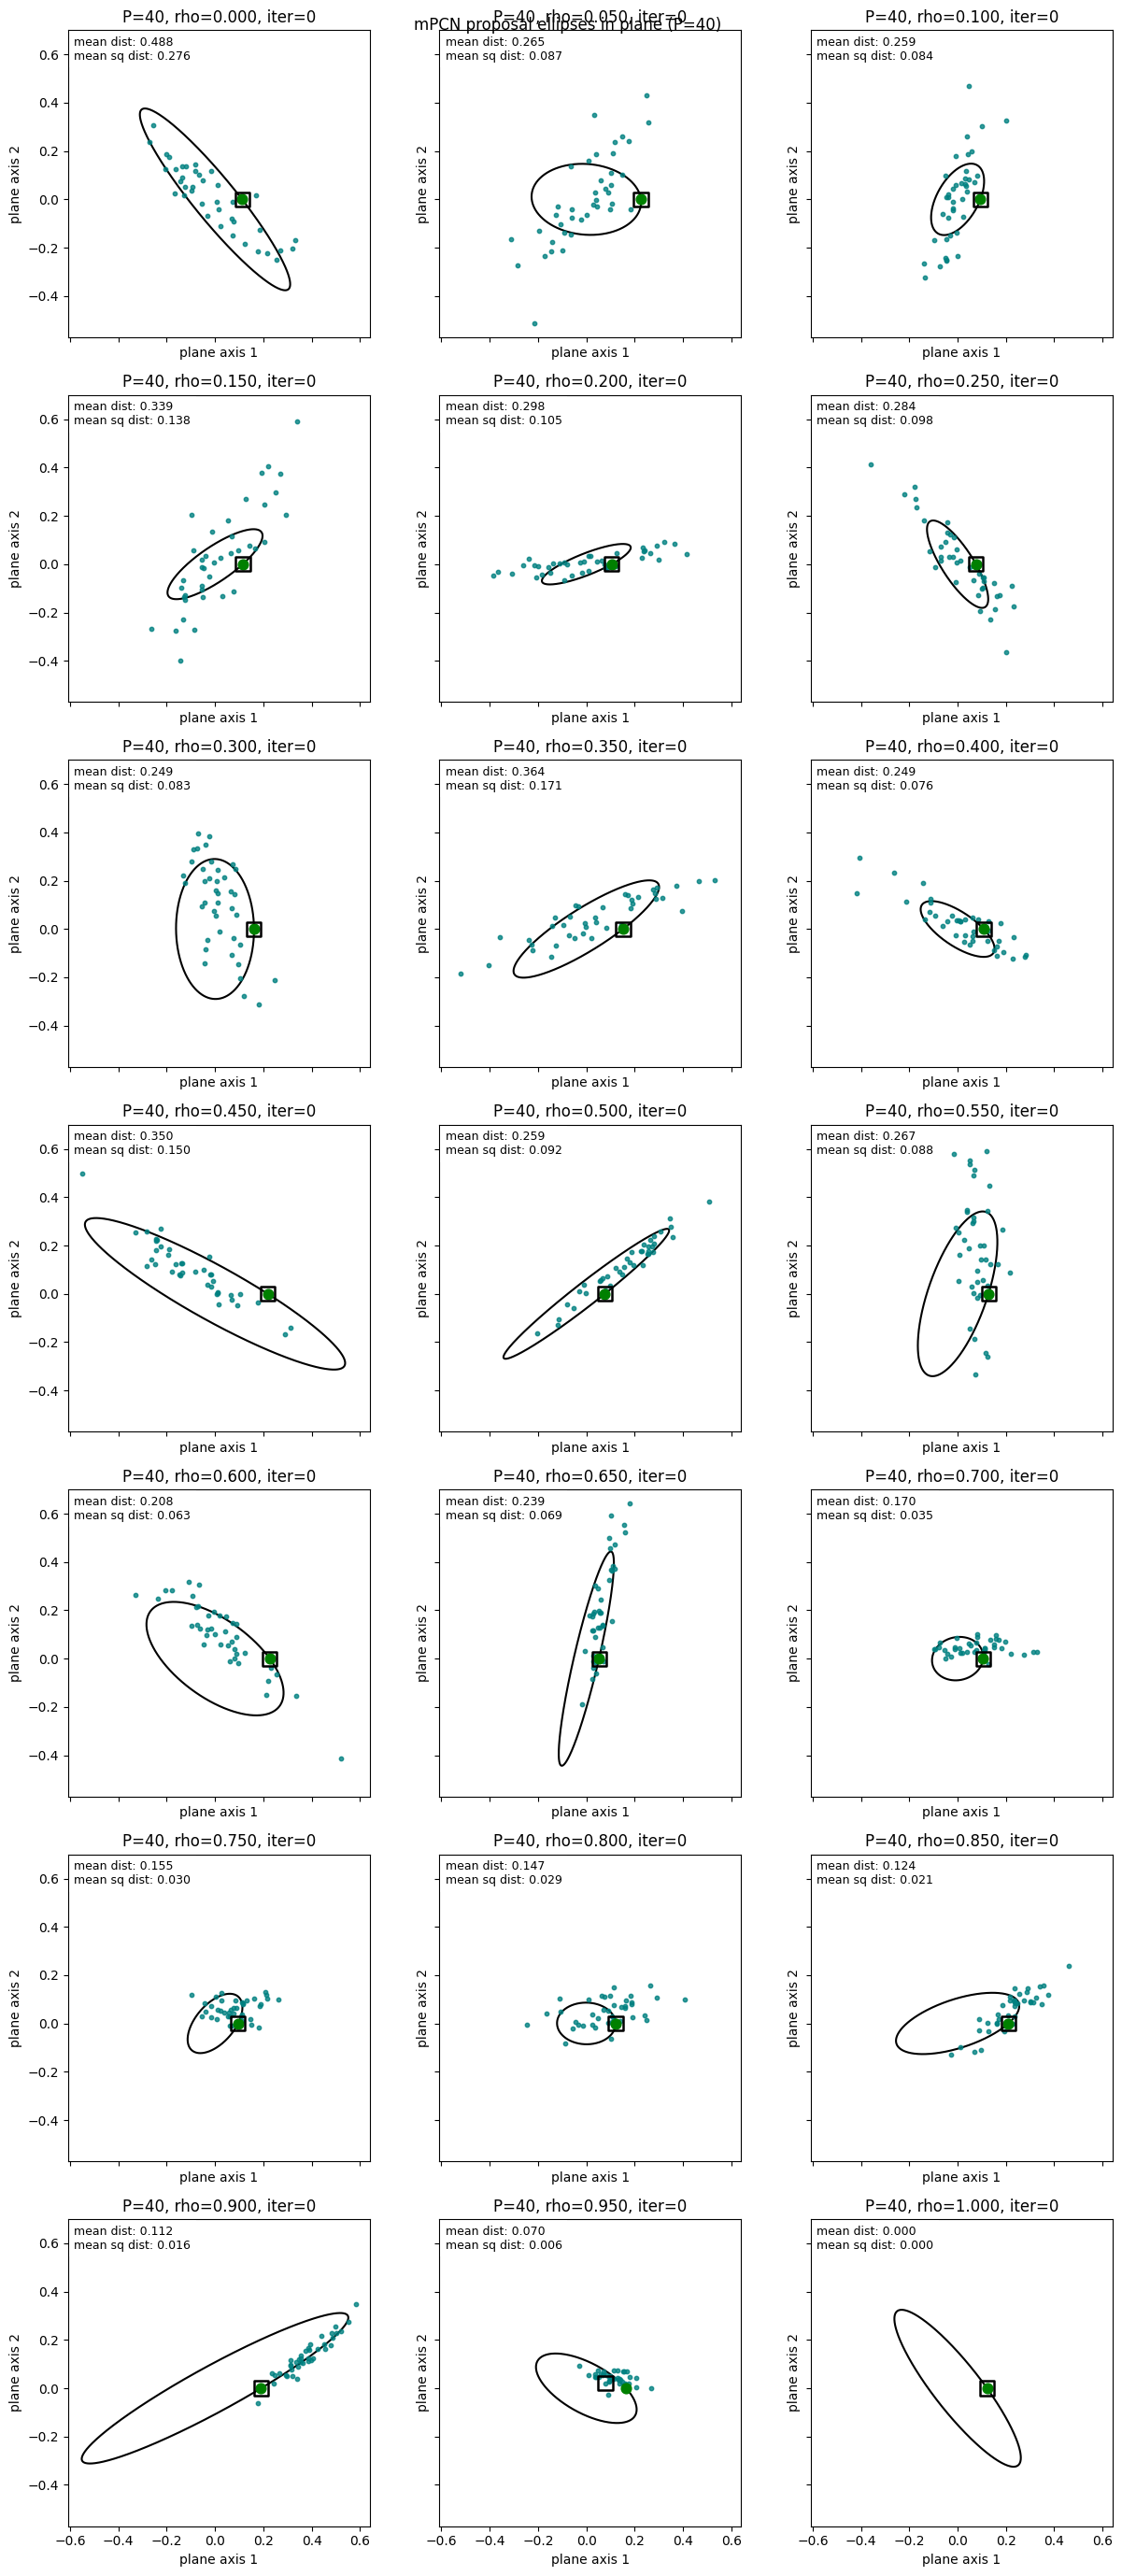

In [11]:
def _plane_basis(x, nu_c, mu):
    u1 = x - mu
    norm1 = np.linalg.norm(u1)
    if norm1 > 0:
        u1 = u1 / norm1
    else:
        u1 = np.zeros_like(x)
        u1[0] = 1.0
    u2 = nu_c - np.dot(nu_c, u1) * u1
    norm2 = np.linalg.norm(u2)
    if norm2 <= 1e-12:
        for k in range(u1.size):
            e = np.zeros_like(u1)
            e[k] = 1.0
            v = e - np.dot(e, u1) * u1
            if np.linalg.norm(v) > 1e-12:
                u2 = v
                break
        norm2 = np.linalg.norm(u2)
    u2 = u2 / norm2 if norm2 > 0 else np.zeros_like(u1)
    return u1, u2


def _project_to_plane(points, mu, u1, u2):
    dif = points - mu[None, :]
    return np.stack([dif @ u1, dif @ u2], axis=-1)


def plot_mpcn_snapshot(ax, snapshot, P, rho, iter_idx):
    if snapshot is None:
        ax.axis('off')
        ax.set_title(f'P={P}, rho={rho:.3f} (no snapshot)')
        return
    mu = np.zeros(problem.dim)
    x = snapshot['x']
    nu_c = snapshot['nu_c']
    props = snapshot['props']
    candidates = snapshot['candidates']
    logy = snapshot['logy']
    accepted_idx = snapshot['accepted_idx']
    mean_dist = snapshot['mean_dist']
    mean_sq_dist = snapshot['mean_sq_dist']

    u1, u2 = _plane_basis(x, nu_c, mu)
    theta = np.linspace(0.0, 2.0 * np.pi, 800)
    ellipse = mu + np.cos(theta)[:, None] * (x - mu) + np.sin(theta)[:, None] * nu_c
    ellipse_2d = _project_to_plane(ellipse, mu, u1, u2)

    prop_log_like = np.array([problem.log_likelihood(p) for p in props])
    above = prop_log_like >= logy
    props_2d = _project_to_plane(props, mu, u1, u2)
    candidates_2d = _project_to_plane(candidates, mu, u1, u2)
    x_2d = _project_to_plane(x[None, :], mu, u1, u2)[0]
    accepted_point = candidates_2d[accepted_idx]

    ax.plot(ellipse_2d[:, 0], ellipse_2d[:, 1], color='black', linewidth=1.5, zorder=2)
    ax.scatter(props_2d[~above, 0], props_2d[~above, 1], color='teal', s=10, alpha=0.8, label='props < logy', zorder=2)
    ax.scatter(props_2d[above, 0], props_2d[above, 1], color='teal', s=10, alpha=0.8, label='props >= logy', zorder=2)
    ax.scatter([x_2d[0]], [x_2d[1]], color='green', s=60, marker='o', label='current', zorder=3)
    ax.scatter([accepted_point[0]], [accepted_point[1]], facecolors='none', edgecolors='black',
               s=120, marker='s', linewidths=1.8, label='accepted', zorder=4)
    ax.text(
        0.02,
        0.98,
        f'mean dist: {mean_dist:.3f}\nmean sq dist: {mean_sq_dist:.3f}',
        transform=ax.transAxes,
        va='top',
        ha='left',
        fontsize=9,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
    )
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('plane axis 1')
    ax.set_ylabel('plane axis 2')
    ax.grid(False)
    ax.set_title(f'P={P}, rho={rho:.3f}, iter={iter_idx}')


reports_dir = repo_root / 'reports' / 'solute_transport'
reports_dir.mkdir(parents=True, exist_ok=True)

n_rho = len(rho_list)
ncols = 3
nrows = int(np.ceil(n_rho / ncols))

for P in P_list[-1:]:
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.0 * nrows), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)
    for ax, rho in zip(axes, rho_list):
        snapshot = results['mpcn'][P][rho]['snapshot']
        plot_mpcn_snapshot(ax, snapshot, P, rho, plot_iter)
    for ax in axes[len(rho_list):]:
        ax.axis('off')
    fig.suptitle(f'mPCN proposal ellipses in plane (P={P})')
    fig.tight_layout()
    fig.savefig(
        reports_dir / f'04_solute_transport_mpcn_ellipses_P{P}_seed{seed_base}.png',
        dpi=300,
        bbox_inches='tight',
    )
    plt.show()

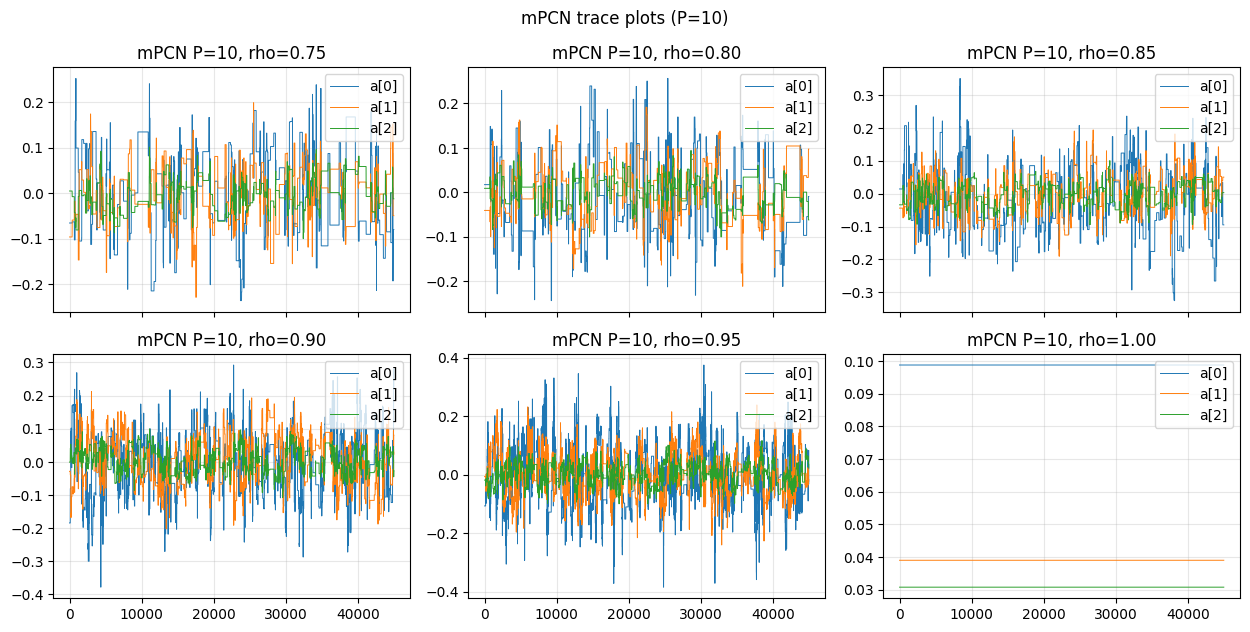

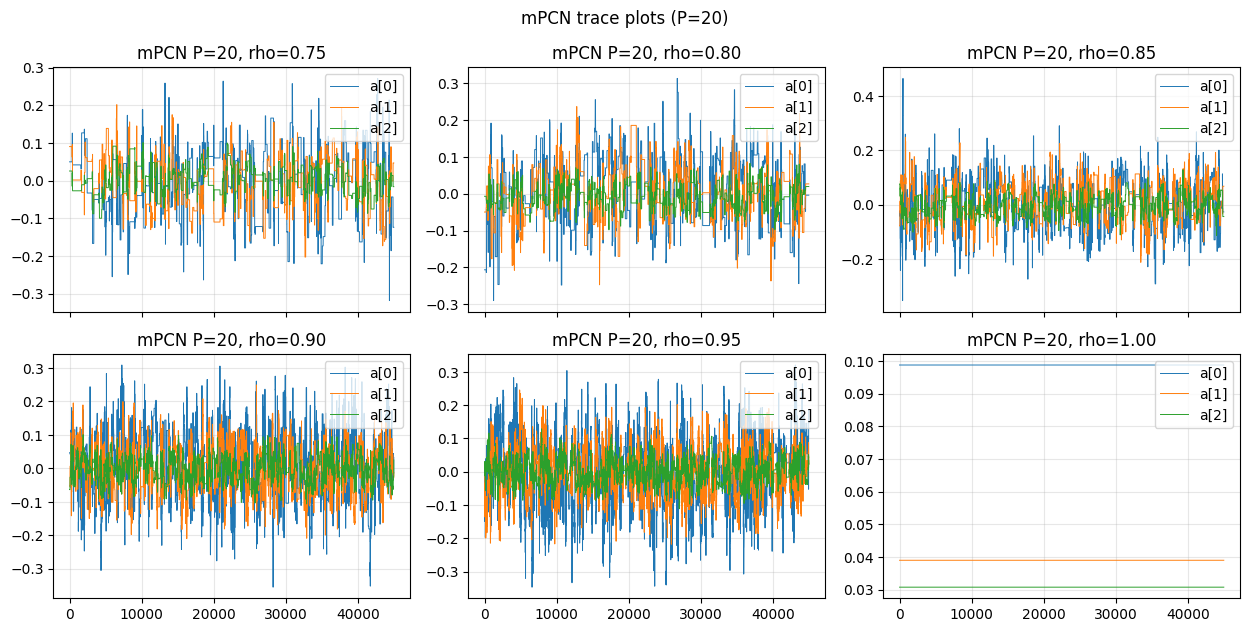

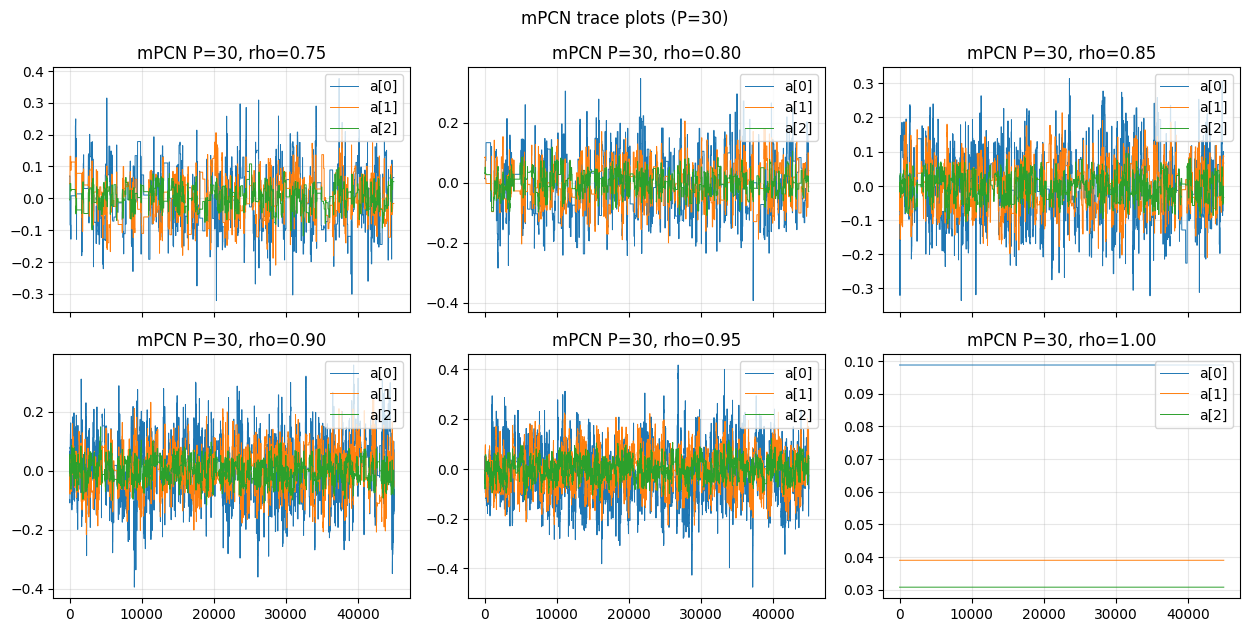

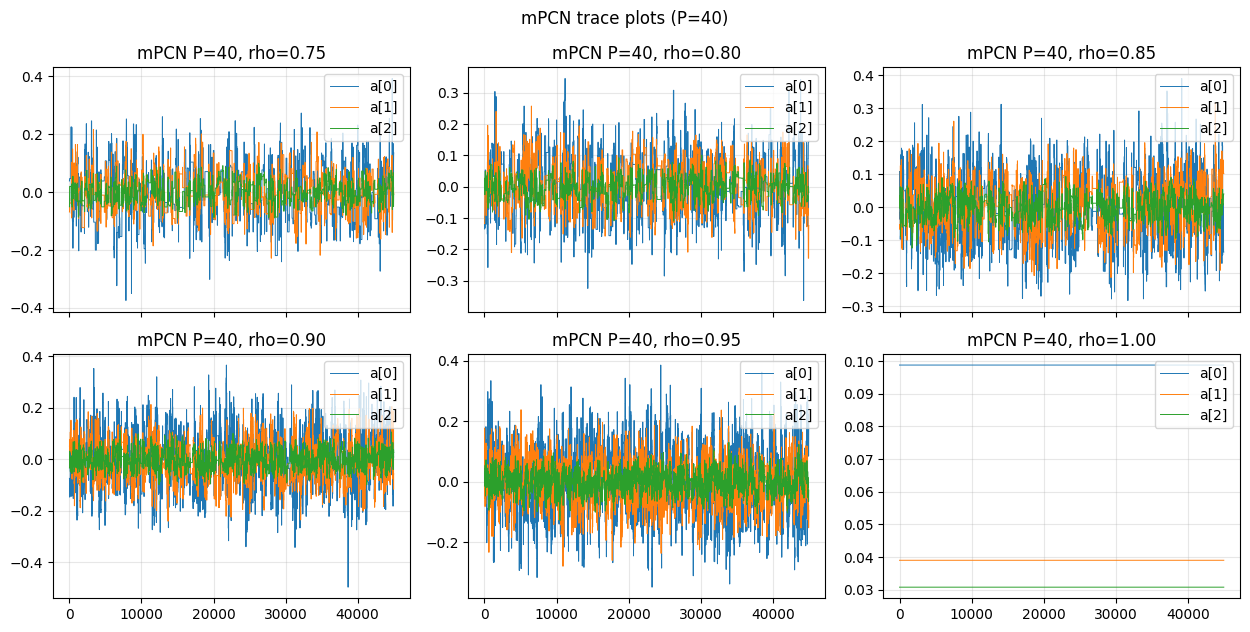

In [12]:
# Trace plots: one figure per P, subplots by rho
rho_list_plot = rho_list[-6:]
param_indices = [0, 1, 2]
param_indices = [idx for idx in param_indices if idx < problem.dim]
ncols = 3
nrows = int(np.ceil(len(rho_list_plot) / ncols))

for P in P_list:
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows), sharex=True)
    axes = np.array(axes).reshape(-1)
    for ax, rho in zip(axes, rho_list_plot):
        chain = results['mpcn'][P][rho]['chain'][burn_in:]
        for idx in param_indices:
            ax.plot(chain[:, idx], linewidth=0.7, label=f'a[{idx}]')
        ax.set_title(f'mPCN P={P}, rho={rho:.2f}')
        ax.grid(alpha=0.3)
        ax.legend(loc='upper right')
    for ax in axes[len(rho_list_plot):]:
        ax.axis('off')
    fig.suptitle(f'mPCN trace plots (P={P})')
    fig.tight_layout()
    plt.savefig(repo_root / 'reports' / 'solute_transport' / f'04_solute_transport_mpcn_traces_P{P}_last6_seed{seed_base}.png', dpi=300)
    plt.show()

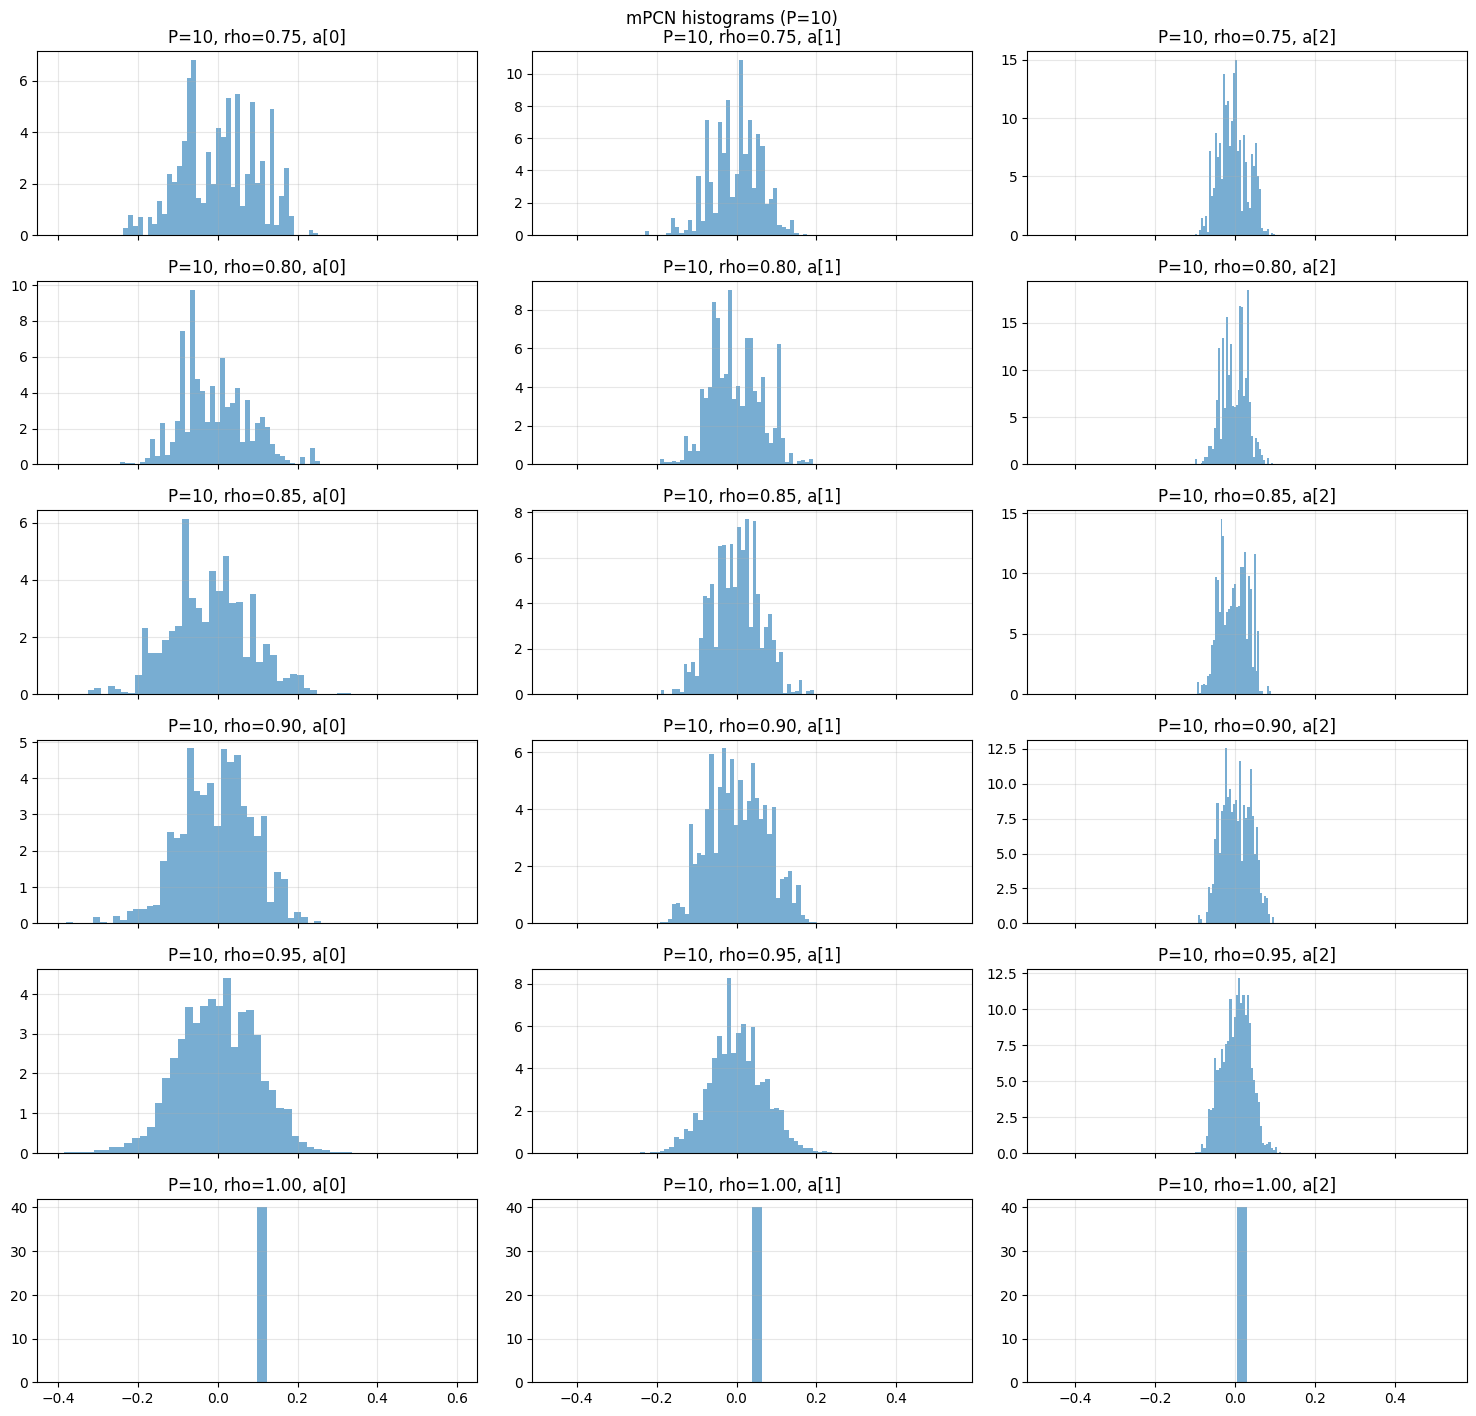

In [13]:
# Histograms: one figure per P, each rho has a panel per parameter
bins = 40
param_indices = [0, 1, 2]
param_indices = [idx for idx in param_indices if idx < problem.dim]

for P in P_list[:1]:
    fig, axes = plt.subplots(len(rho_list_plot), len(param_indices), figsize=(5 * len(param_indices), 2.4 * len(rho_list_plot)), sharex='col')
    if len(param_indices) == 1:
        axes = axes[:, None]
    for row_idx, rho in enumerate(rho_list_plot):
        chain = results['mpcn'][P][rho]['chain'][burn_in:]
        for col_idx, p_idx in enumerate(param_indices):
            ax = axes[row_idx, col_idx]
            ax.hist(chain[:, p_idx], bins=bins, density=True, alpha=0.6)
            ax.set_title(f'P={P}, rho={rho:.2f}, a[{p_idx}]')
            ax.grid(alpha=0.3)
    fig.suptitle(f'mPCN histograms (P={P})')
    fig.tight_layout()
    plt.savefig(repo_root / 'reports' / 'solute_transport' / f'04_solute_transport_mpcn_histograms_P{P}_last6_seed{seed_base}.png', dpi=300)
    plt.show()

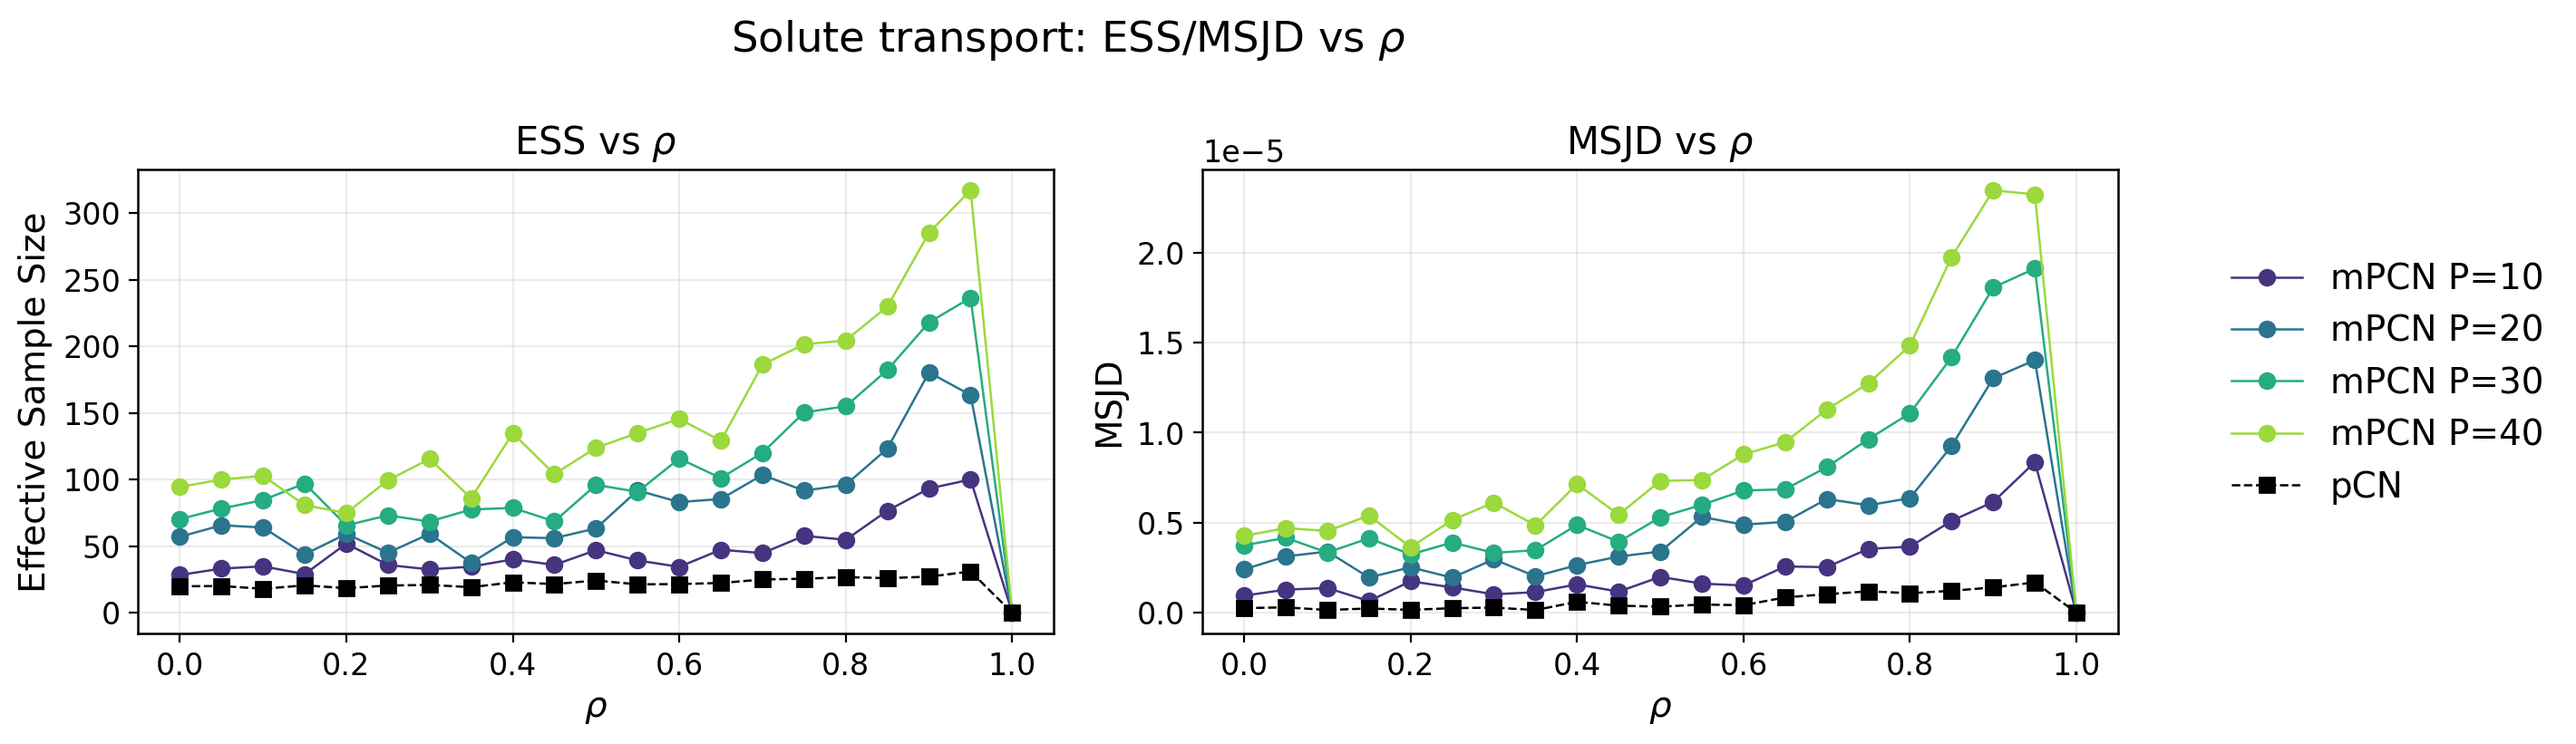

In [14]:
# ESS/MSJD vs rho curves (one line per P)
apply_pub_style()

P_sorted = sorted(P_list)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(P_sorted)))
color_by_P = {P: colors[i] for i, P in enumerate(P_sorted)}
show_mess = False
show_pcn = True

pcn_ess = None
pcn_msjd = None
if run_pcn and results['pcn']:
    pcn_ess = [results['pcn'][rho]['metrics']['ess_mean'] for rho in rho_list]
    pcn_msjd = [results['pcn'][rho]['metrics']['msjd_mean'] for rho in rho_list]

reports_dir = repo_root / 'reports' / 'solute_transport'
reports_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), sharex=True)
ax_ess, ax_msjd = axes

for P in P_sorted:
    ess_vals = [results['mpcn'][P][rho]['metrics']['ess_mean'] for rho in rho_list]
    ax_ess.plot(rho_list, ess_vals, marker='o', color=color_by_P[P], label=f'mPCN P={P}')
if show_pcn and pcn_ess is not None:
    ax_ess.plot(rho_list, pcn_ess, color='black', marker='s', linestyle='--', label='pCN')
if show_mess and run_mess:
    for P in P_sorted:
        mess_uniform = results['mess_uniform'][P]['metrics']['ess_mean']
        mess_euclid = results['mess_euclid_sq'][P]['metrics']['ess_mean']
        ax_ess.plot(rho_list, [mess_uniform] * len(rho_list), linestyle='--', color=color_by_P[P], alpha=0.6)
        ax_ess.plot(rho_list, [mess_euclid] * len(rho_list), linestyle=':', color=color_by_P[P], alpha=0.6)
ax_ess.set_xlabel(r'$\rho$')
ax_ess.set_ylabel('Effective Sample Size')
ax_ess.set_title(r'ESS vs $\rho$')
ax_ess.grid(alpha=0.25)

for P in P_sorted:
    msjd_vals = [results['mpcn'][P][rho]['metrics']['msjd_mean'] for rho in rho_list]
    ax_msjd.plot(rho_list, msjd_vals, marker='o', color=color_by_P[P], label=f'mPCN P={P}')
if show_pcn and pcn_msjd is not None:
    ax_msjd.plot(rho_list, pcn_msjd, color='black', marker='s', linestyle='--', label='pCN')
if show_mess and run_mess:
    for P in P_sorted:
        mess_uniform = results['mess_uniform'][P]['metrics']['msjd_mean']
        mess_euclid = results['mess_euclid_sq'][P]['metrics']['msjd_mean']
        ax_msjd.plot(rho_list, [mess_uniform] * len(rho_list), linestyle='--', color=color_by_P[P], alpha=0.6)
        ax_msjd.plot(rho_list, [mess_euclid] * len(rho_list), linestyle=':', color=color_by_P[P], alpha=0.6)
ax_msjd.set_xlabel(r'$\rho$')
ax_msjd.set_ylabel('MSJD')
ax_msjd.set_title(r'MSJD vs $\rho$')
ax_msjd.grid(alpha=0.25)

handles = []
labels = []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in labels:
            labels.append(ll)
            handles.append(hh)
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle(r'Solute transport: ESS/MSJD vs $\rho$')
fig.tight_layout()
fig.savefig(reports_dir / f'solute_transport_ess_msjd_vs_rho_seed{seed_base}.png', bbox_inches='tight')
plt.show()

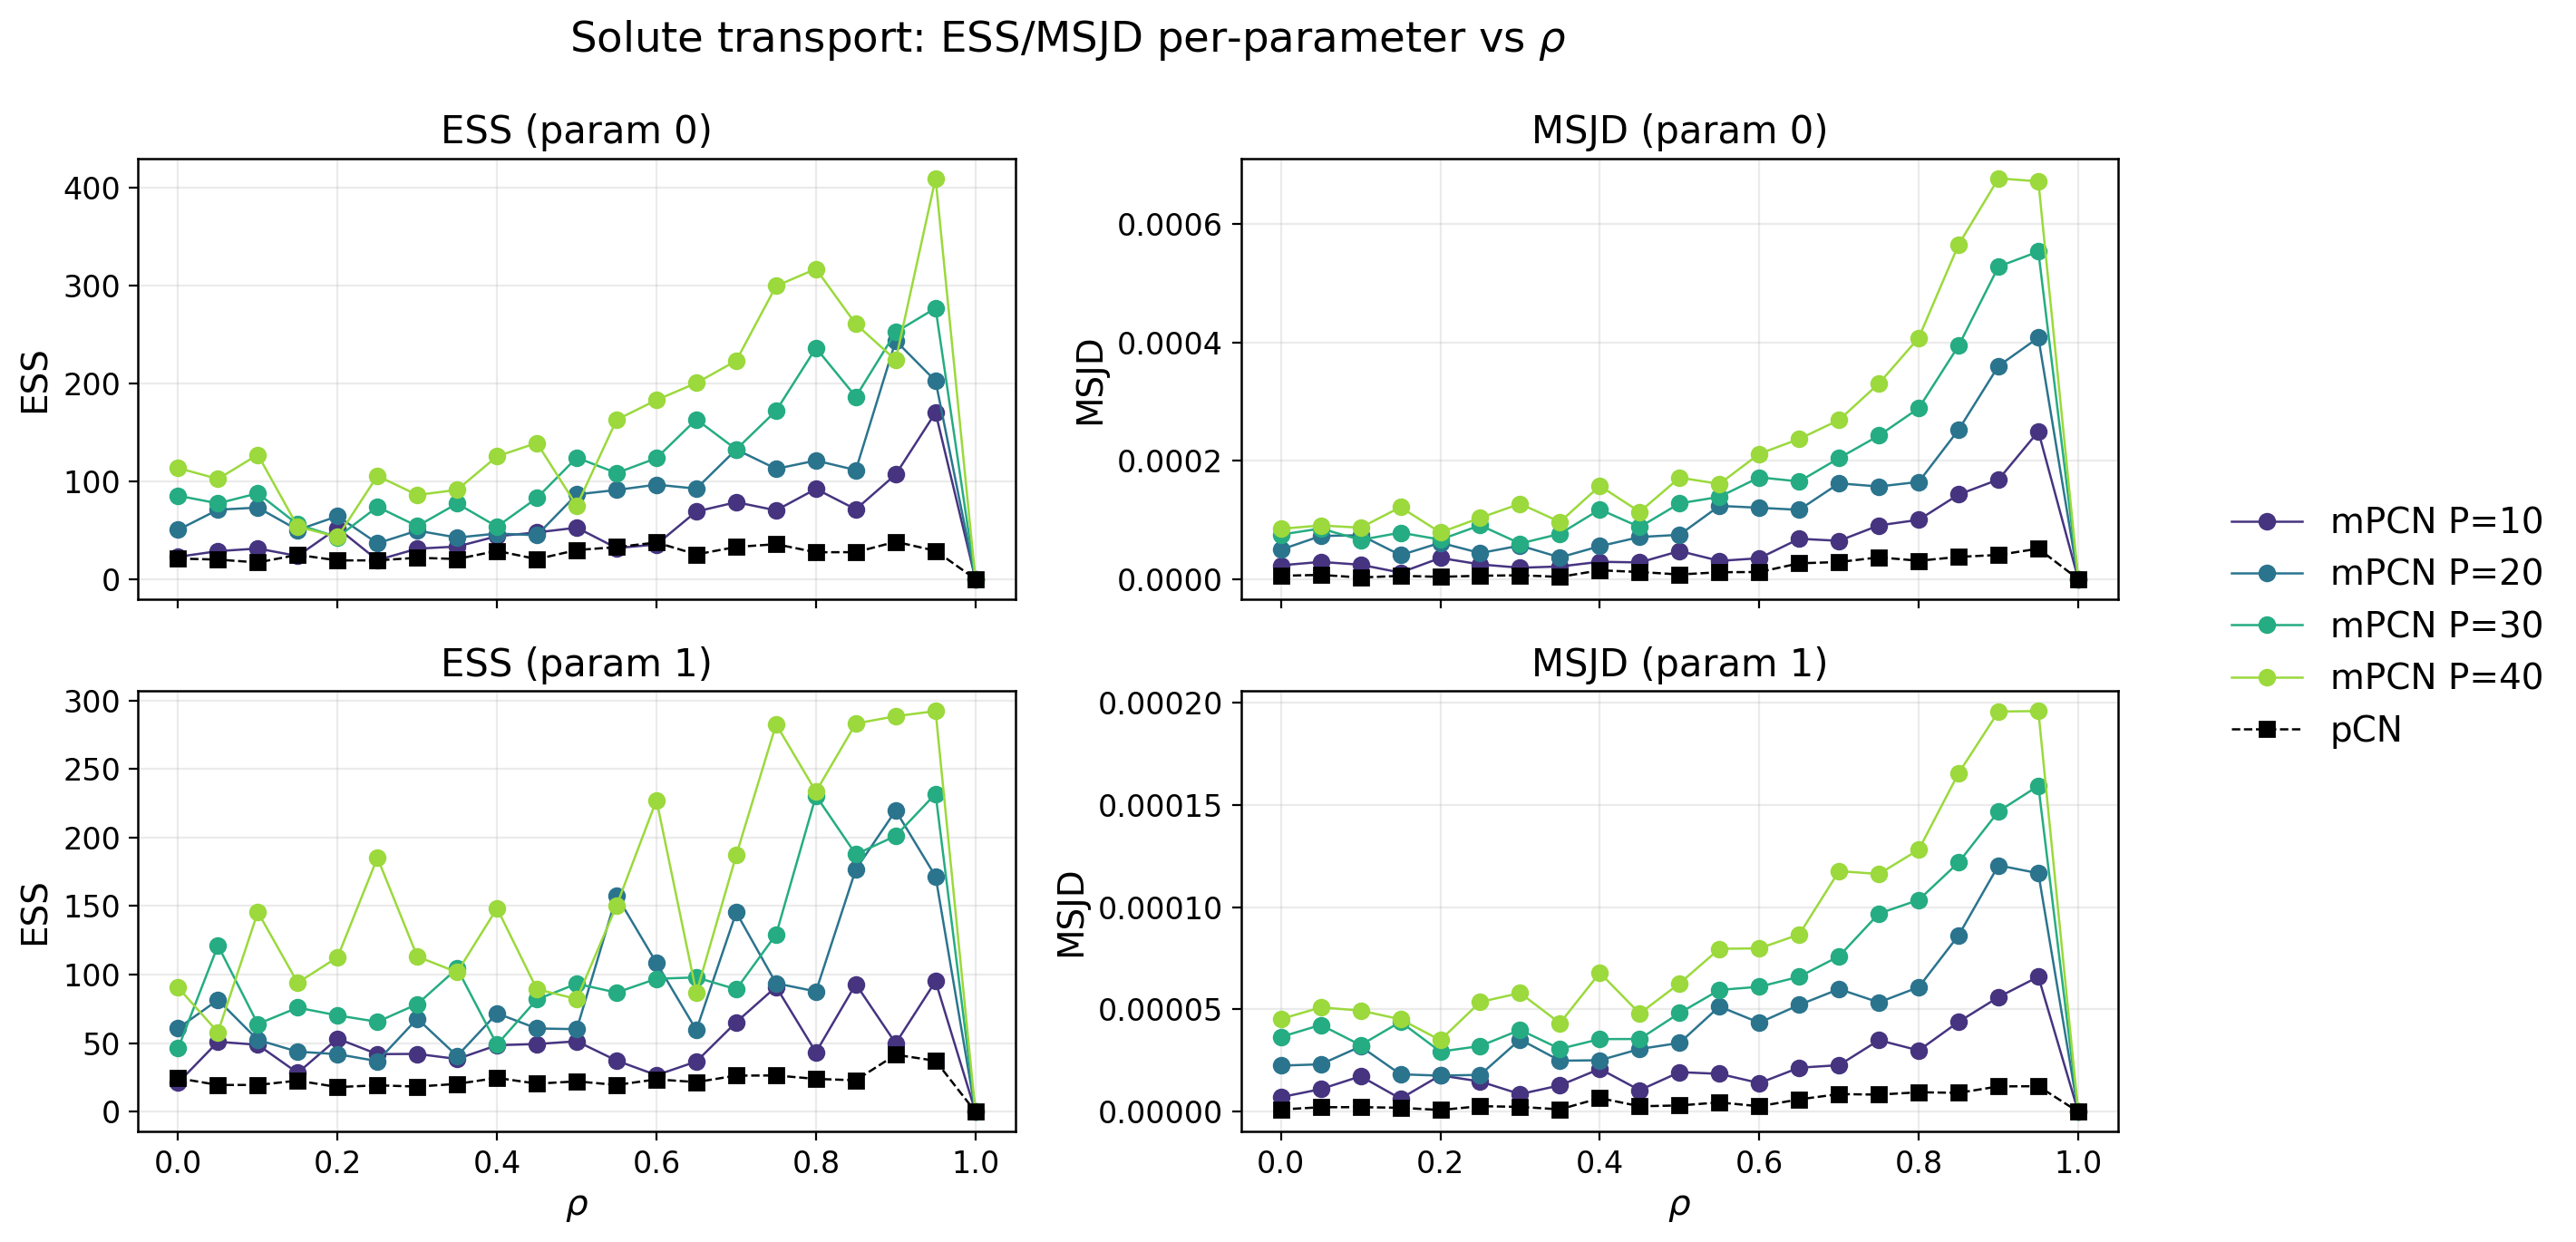

In [15]:
# ESS/MSJD per-parameter vs rho (full range + edges)
apply_pub_style()

P_sorted = sorted(P_list)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(P_sorted)))
color_by_P = {P: colors[i] for i, P in enumerate(P_sorted)}
show_pcn = True

def get_param_metric(results_dict, P, rho, metric_key, param_index):
    entry = results_dict.get(P, {}).get(float(rho))
    if entry is None:
        return np.nan
    values = entry['metrics'].get(metric_key)
    if values is None or len(values) <= param_index:
        return np.nan
    return values[param_index]

reports_dir = repo_root / 'reports' / 'solute_transport'
reports_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12.0, 7.0), sharex=True)
for P in P_sorted:
    ess_p0 = [get_param_metric(results['mpcn'], P, rho, 'ess_per_param', 0) for rho in rho_list]
    ess_p1 = [get_param_metric(results['mpcn'], P, rho, 'ess_per_param', 1) for rho in rho_list]
    msjd_p0 = [get_param_metric(results['mpcn'], P, rho, 'msjd_per_param', 0) for rho in rho_list]
    msjd_p1 = [get_param_metric(results['mpcn'], P, rho, 'msjd_per_param', 1) for rho in rho_list]
    axes[0, 0].plot(rho_list, ess_p0, marker='o', color=color_by_P[P], label=f'mPCN P={P}')
    axes[1, 0].plot(rho_list, ess_p1, marker='o', color=color_by_P[P])
    axes[0, 1].plot(rho_list, msjd_p0, marker='o', color=color_by_P[P])
    axes[1, 1].plot(rho_list, msjd_p1, marker='o', color=color_by_P[P])

if show_pcn and run_pcn and results['pcn']:
    pcn_ess_p0 = [results['pcn'][rho]['metrics']['ess_per_param'][0] for rho in rho_list]
    pcn_ess_p1 = [results['pcn'][rho]['metrics']['ess_per_param'][1] for rho in rho_list]
    pcn_msjd_p0 = [results['pcn'][rho]['metrics']['msjd_per_param'][0] for rho in rho_list]
    pcn_msjd_p1 = [results['pcn'][rho]['metrics']['msjd_per_param'][1] for rho in rho_list]
    axes[0, 0].plot(rho_list, pcn_ess_p0, color='black', marker='s', linestyle='--', label='pCN')
    axes[1, 0].plot(rho_list, pcn_ess_p1, color='black', marker='s', linestyle='--')
    axes[0, 1].plot(rho_list, pcn_msjd_p0, color='black', marker='s', linestyle='--')
    axes[1, 1].plot(rho_list, pcn_msjd_p1, color='black', marker='s', linestyle='--')

axes[0, 0].set_title('ESS (param 0)')
axes[0, 1].set_title('MSJD (param 0)')
axes[1, 0].set_title('ESS (param 1)')
axes[1, 1].set_title('MSJD (param 1)')
for ax in axes[1, :]:
    ax.set_xlabel(r'$\rho$')
axes[0, 0].set_ylabel('ESS')
axes[1, 0].set_ylabel('ESS')
axes[0, 1].set_ylabel('MSJD')
axes[1, 1].set_ylabel('MSJD')
for ax in axes.ravel():
    ax.grid(alpha=0.25)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle(r'Solute transport: ESS/MSJD per-parameter vs $\rho$')
fig.tight_layout()
fig.savefig(
    reports_dir / f'solute_transport_ess_msjd_per_param_vs_rho_seed{seed_base}.png',
    bbox_inches='tight',
)
plt.show()

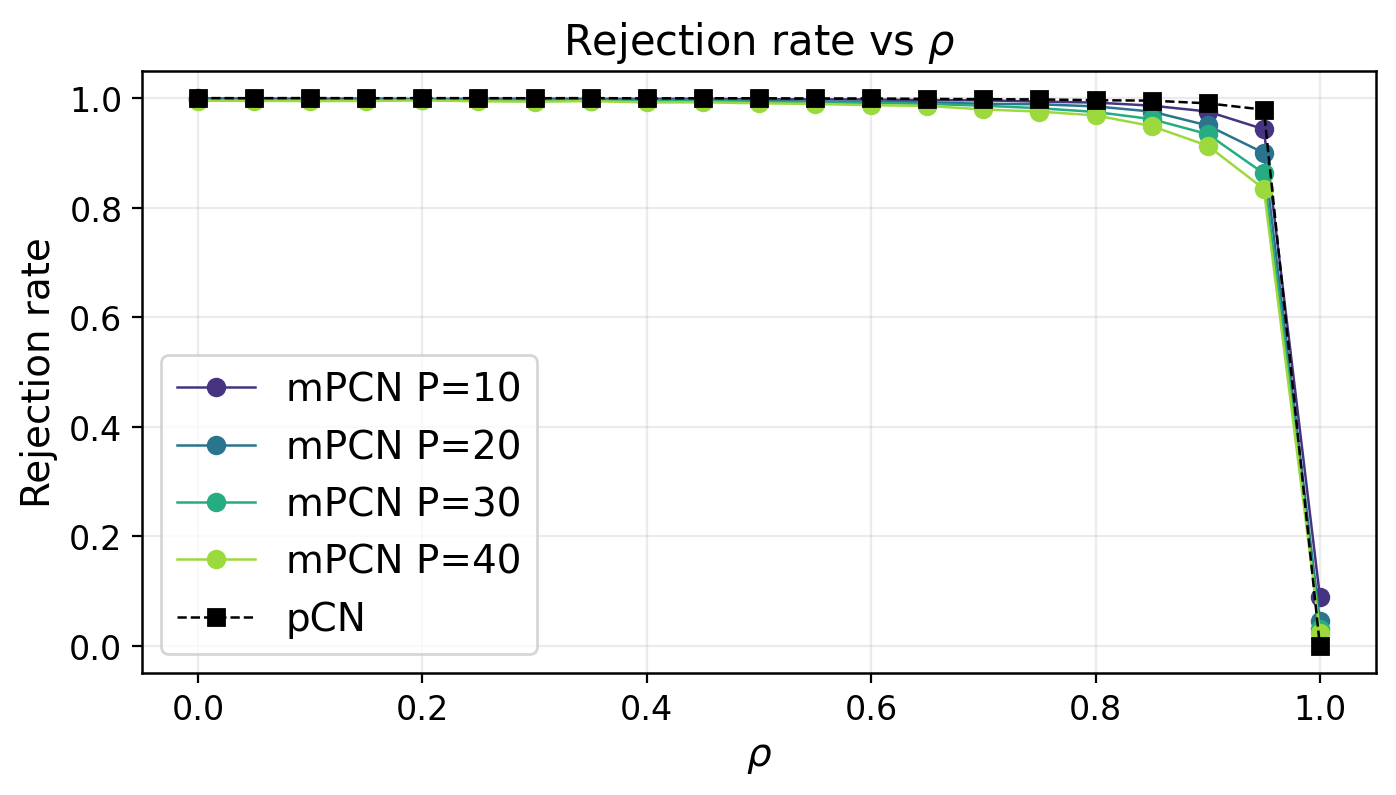

In [16]:
# Rejection rate vs rho (one line per P)
apply_pub_style()

P_sorted = sorted(P_list)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(P_sorted)))
color_by_P = {P: colors[i] for i, P in enumerate(P_sorted)}
show_pcn = True

pcn_reject = None
if run_pcn and results['pcn']:
    pcn_reject = [1.0 - results['pcn'][rho]['accept_rate'] for rho in rho_list]

reports_dir = repo_root / 'reports' / 'solute_transport'
reports_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(1, 1, figsize=(7.2, 4.2), sharex=True)

for P in P_sorted:
    reject_vals = [1.0 - results['mpcn'][P][rho]['accept_rate'] for rho in rho_list]
    ax.plot(rho_list, reject_vals, marker='o', color=color_by_P[P], label=f'mPCN P={P}')
if show_pcn and pcn_reject is not None:
    ax.plot(rho_list, pcn_reject, color='black', marker='s', linestyle='--', label='pCN')

ax.set_xlabel(r'$\rho$')
ax.set_ylabel('Rejection rate')
ax.set_title(r'Rejection rate vs $\rho$')
ax.grid(alpha=0.25)
ax.legend(loc='best')

fig.tight_layout()
fig.savefig(reports_dir / f'solute_transport_rejection_vs_rho_seed{seed_base}.png', bbox_inches='tight')
plt.show()

In [17]:
# ESS/MSJD tables (rows=P, columns=rho + pCN)
ess_rows = []
msjd_rows = []
row_labels = []
col_labels = [f'rho={rho:.3f}' for rho in rho_list]

for P in P_list:
    ess_row = [results['mpcn'][P][rho]['metrics']['ess_mean'] for rho in rho_list]
    msjd_row = [results['mpcn'][P][rho]['metrics']['msjd_mean'] for rho in rho_list]
    ess_rows.append(ess_row)
    msjd_rows.append(msjd_row)
    row_labels.append(f'P={P}')

if run_pcn and results['pcn']:
    ess_row = [results['pcn'][rho]['metrics']['ess_mean'] for rho in rho_list]
    msjd_row = [results['pcn'][rho]['metrics']['msjd_mean'] for rho in rho_list]
    ess_rows.append(ess_row)
    msjd_rows.append(msjd_row)
    row_labels.append('pCN')

ess_table = pd.DataFrame(ess_rows, index=row_labels, columns=col_labels)
msjd_table = pd.DataFrame(msjd_rows, index=row_labels, columns=col_labels)

ess_table_display = ess_table.round(0).astype(int)
msjd_table_display = msjd_table.round(3)
print('ESS table (mPCN across rho; pCN row if enabled):')
display(ess_table_display)
print('MSJD table (mPCN across rho; pCN row if enabled):')
display(msjd_table_display)

ESS table (mPCN across rho; pCN row if enabled):


,rho=0.000,rho=0.050,rho=0.100,rho=0.150,rho=0.200,rho=0.250,rho=0.300,rho=0.350,rho=0.400,rho=0.450,...,rho=0.550,rho=0.600,rho=0.650,rho=0.700,rho=0.750,rho=0.800,rho=0.850,rho=0.900,rho=0.950,rho=1.000
P=10,28,33,35,29,52,36,33,35,40,36,...,39,34,47,45,58,55,77,93,100,0
P=20,57,66,64,44,59,45,59,37,57,56,...,92,83,85,103,92,96,123,180,163,0
P=30,70,78,85,97,66,73,68,78,79,69,...,91,116,101,120,150,155,182,218,236,0
P=40,95,100,103,81,75,99,116,86,135,104,...,135,146,129,186,202,204,230,285,317,0
pCN,20,20,18,21,18,20,21,19,23,22,...,21,22,22,25,26,27,26,27,31,0


MSJD table (mPCN across rho; pCN row if enabled):


,rho=0.000,rho=0.050,rho=0.100,rho=0.150,rho=0.200,rho=0.250,rho=0.300,rho=0.350,rho=0.400,rho=0.450,...,rho=0.550,rho=0.600,rho=0.650,rho=0.700,rho=0.750,rho=0.800,rho=0.850,rho=0.900,rho=0.950,rho=1.000
P=10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P=20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P=30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P=40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pCN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Analyzing mixing for extreme rho

In [18]:
# Run extra rho chains for the edge ranges
rho_low = np.round(np.arange(0.0, 0.1001, 0.005), 5)
rho_high = np.round(np.arange(0.85, 1.0001, 0.005), 5)
rho_edges = np.unique(np.concatenate([rho_low, rho_high]))

def ensure_mpcn_rho_results(rho_values):
    for P in P_list:
        results['mpcn'].setdefault(P, {})
        for rho in rho_values:
            rho_key = float(rho)
            if rho_key in results['mpcn'][P]:
                continue
            samples_path, metrics_path = chain_cache_paths(
                'mpcn', rho=rho_key, seed_base=seed_base, P=P
            )
            diag_path = mpcn_diag_path(P, rho_key, seed_base)
            loaded = load_chain_bundle(samples_path, metrics_path)
            if loaded is not None:
                chain, accept_rate, runtime_sec, metrics = loaded
                if metrics is None or 'ess_per_param' not in metrics:
                    metrics = summarize_chain_metrics(
                        chain, runtime_sec, burn_in=burn_in, max_lag=max_lag
                    )
                    save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec)
                snapshot, mean_dist_samples, mean_sq_dist_samples = load_mpcn_diagnostics(diag_path)
                results['mpcn'][P][rho_key] = {
                    'chain': chain,
                    'runtime_sec': runtime_sec,
                    'accept_rate': accept_rate,
                    'metrics': metrics,
                    'snapshot': snapshot,
                    'mean_dist_samples': np.asarray(mean_dist_samples, dtype=float),
                    'mean_sq_dist_samples': np.asarray(mean_sq_dist_samples, dtype=float),
                }
                accept_display = np.nan if accept_rate is None else accept_rate
                print(
                    f'mPCN edge rho loaded: P={P}, rho={rho_key:.3f}, '
                    f'accept={accept_display:.3f}, runtime={runtime_sec:.2f}s'
                )
                continue
            seed = seed_base + int(P * 1000 + round(rho_key * 1000))

            chain, runtime_sec, accept_rate, _ = run_mpcn_chain(
                problem,
                x0,
                n_iters,
                rho=rho_key,
                n_props=P,
                seed=seed,
                diag_indices=None,
            )
            metrics = summarize_chain_metrics(chain, runtime_sec, burn_in=burn_in, max_lag=max_lag)
            save_chain_bundle(samples_path, metrics_path, chain, accept_rate, runtime_sec, metrics)
            save_mpcn_diagnostics(diag_path, None, [], [])
            results['mpcn'][P][rho_key] = {
                'chain': chain,
                'runtime_sec': runtime_sec,
                'accept_rate': accept_rate,
                'metrics': metrics,
                'snapshot': None,
                'mean_dist_samples': np.asarray([], dtype=float),
                'mean_sq_dist_samples': np.asarray([], dtype=float),
            }
            print(
                f'mPCN edge rho done: P={P}, rho={rho_key:.3f}, '
                f'accept={accept_rate:.3f}, runtime={runtime_sec:.2f}s'
            )

ensure_mpcn_rho_results(rho_edges)

mPCN edge rho loaded: P=10, rho=0.005, accept=0.001, runtime=8.82s
mPCN edge rho loaded: P=10, rho=0.010, accept=0.001, runtime=8.91s
mPCN edge rho loaded: P=10, rho=0.015, accept=0.001, runtime=9.03s
mPCN edge rho loaded: P=10, rho=0.020, accept=0.001, runtime=9.09s
mPCN edge rho loaded: P=10, rho=0.025, accept=0.001, runtime=9.03s
mPCN edge rho loaded: P=10, rho=0.030, accept=0.002, runtime=9.01s
mPCN edge rho loaded: P=10, rho=0.035, accept=0.001, runtime=9.01s
mPCN edge rho loaded: P=10, rho=0.040, accept=0.002, runtime=9.08s
mPCN edge rho loaded: P=10, rho=0.045, accept=0.001, runtime=9.08s
mPCN edge rho loaded: P=10, rho=0.055, accept=0.001, runtime=9.13s
mPCN edge rho loaded: P=10, rho=0.060, accept=0.002, runtime=9.05s
mPCN edge rho loaded: P=10, rho=0.065, accept=0.001, runtime=9.17s
mPCN edge rho loaded: P=10, rho=0.070, accept=0.002, runtime=9.15s
mPCN edge rho loaded: P=10, rho=0.075, accept=0.002, runtime=9.14s
mPCN edge rho loaded: P=10, rho=0.080, accept=0.002, runtime=9

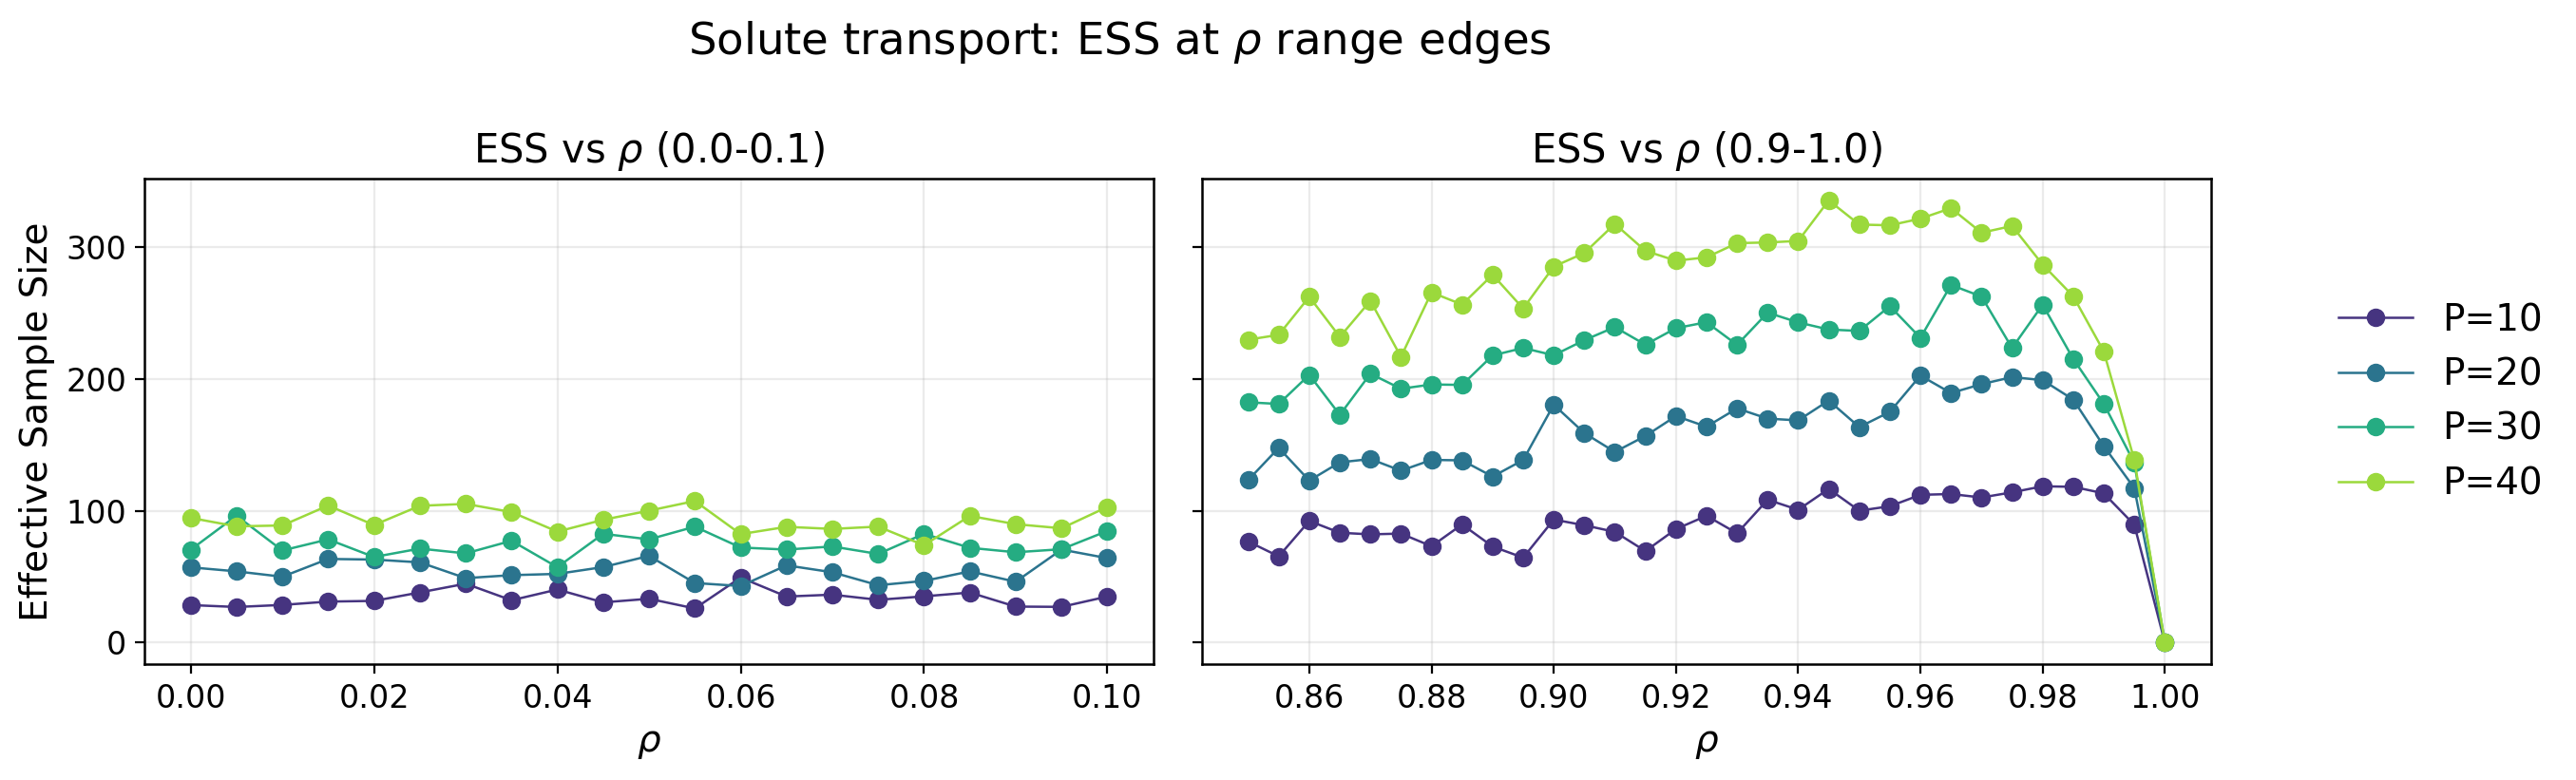

In [19]:
# Zoomed-in rho ranges (0-0.1 and 0.9-1.0)
apply_pub_style()

rho_low = np.round(np.arange(0.0, 0.1001, 0.005), 5)
rho_high = np.round(np.arange(0.85, 1.0001, 0.005), 5)

P_sorted = sorted(P_list)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(P_sorted)))
color_by_P = {P: colors[i] for i, P in enumerate(P_sorted)}

def get_metric_for_rho(results_dict, P, rho, metric_key):
    entry = results_dict.get(P, {}).get(float(rho))
    if entry is None:
        return np.nan
    return entry['metrics'][metric_key]

reports_dir = repo_root / 'reports' / 'solute_transport'
reports_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), sharey=True)
ax_low, ax_high = axes

for P in P_sorted:
    ess_low = [get_metric_for_rho(results['mpcn'], P, rho, 'ess_mean') for rho in rho_low]
    ess_high = [get_metric_for_rho(results['mpcn'], P, rho, 'ess_mean') for rho in rho_high]
    ax_low.plot(rho_low, ess_low, marker='o', color=color_by_P[P], label=f'P={P}')
    ax_high.plot(rho_high, ess_high, marker='o', color=color_by_P[P], label=f'P={P}')

ax_low.set_title(r'ESS vs $\rho$ (0.0-0.1)')
ax_low.set_xlabel(r'$\rho$')
ax_low.set_ylabel('Effective Sample Size')
ax_low.grid(alpha=0.25)

ax_high.set_title(r'ESS vs $\rho$ (0.9-1.0)')
ax_high.set_xlabel(r'$\rho$')
ax_high.grid(alpha=0.25)

handles, labels = ax_low.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle(r'Solute transport: ESS at $\rho$ range edges')
fig.tight_layout()

filename = f'solute_transport_ess_rho_edges_0.00-0.10_0.85-1.00_seed{seed_base}.png'
fig.savefig(reports_dir / filename, bbox_inches='tight')
plt.show()

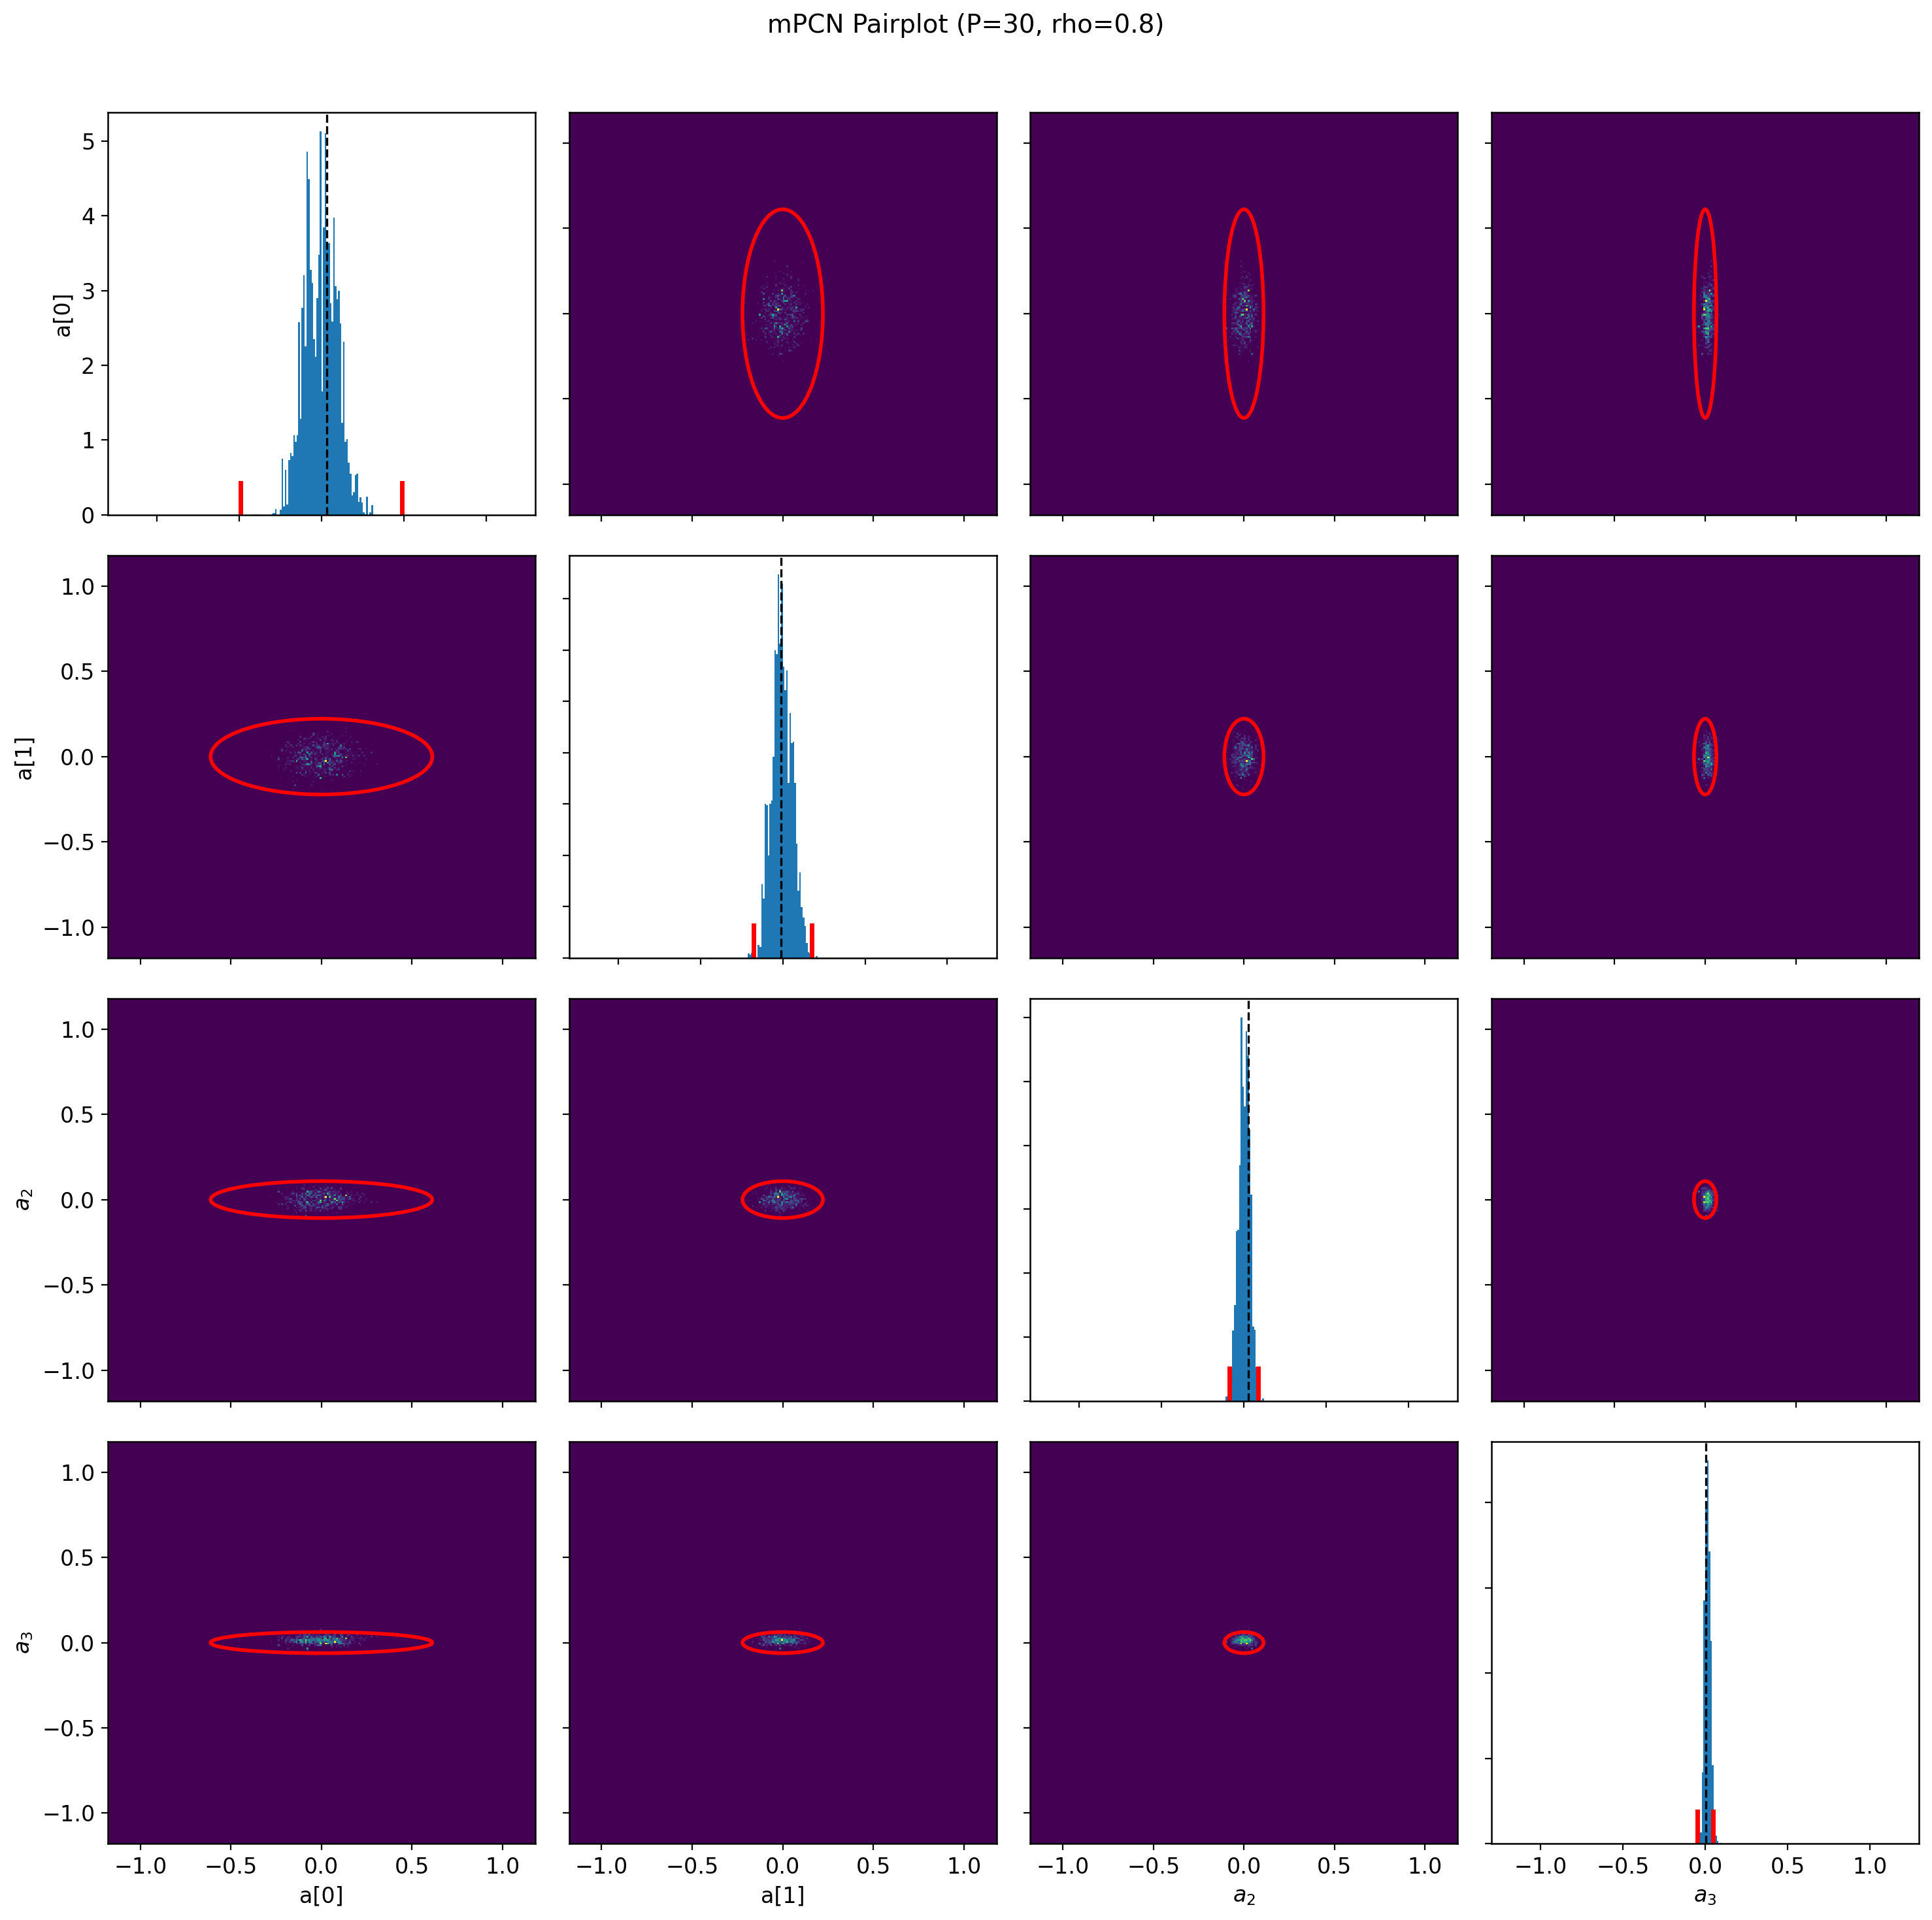

In [20]:
# Pairplots for a selected P and rho
from multiproposal.plotting.diagnostics import make_hist_grid_comps

P_pair = 30
rho_pair = 0.8

comp_list = [0, 1, 2, 3]
comp_list = [idx for idx in comp_list if idx < problem.dim]
if len(comp_list) < 2:
    raise ValueError('Need at least two parameters for pairplots.')

post_chain_mpcn = results['mpcn'][P_pair][rho_pair]['chain'][burn_in:]
# post_chain_mess_uniform = results['mess_uniform'][P_pair]['chain'][burn_in:]
# post_chain_mess_euclid = results['mess_euclid_sq'][P_pair]['chain'][burn_in:]

# combined = np.vstack([post_chain_mpcn, post_chain_mess_uniform, post_chain_mess_euclid])
combined = np.vstack([post_chain_mpcn])
R = 3 * np.max(np.abs(combined))
dr = 0.01

prior_cov = np.diag(data['prior_diag'])
label_map = {comp_list[0]: f'a[{comp_list[0]}]', comp_list[1]: f'a[{comp_list[1]}]'}
true_values = data.get('a_true', None)

_ = make_hist_grid_comps(
    R=R,
    dr=dr,
    samples=post_chain_mpcn,
    comp_list=comp_list,
    save_path=reports_dir / f'solute_transport_mpcn_pairplot_P{P_pair}_rho{rho_pair:.2f}_seed{seed_base}.png',
    C=prior_cov,
    beta=0.95,
    hide_plot=False,
    label_map=label_map,
    font_size=12,
    title=f'mPCN Pairplot (P={P_pair}, rho={rho_pair:.1f})',
    true_values=true_values,
 )